# HP k=35 and k=36 Family Analysis

Analyze the matches from HP k=35 and k=36 with TF-IDF > 1000 - the minimum k-sizes that outperform FoldSeek (AUC=0.574) and TEA (AUC=0.580).

Goals:
1. Load k=35 and k=36 HP results with TF-IDF > 1000
2. Compare families/superfamilies represented vs FoldSeek and TEA
3. Identify what's similar between k=35 and k=36 matches
4. Determine if particular SCOPe families are enriched in HP results

In [5]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
import sys

# Add notebook directory to path for imports
sys.path.insert(0, str(Path.cwd()))
from scope_kmerseek_utils import (
    read_csv_with_size_limit,
    kmerseek_to_rocx,
    load_rocx_file,
    plot_sensitivity_from_rocx,
    compute_auc,
    extract_scope_levels,
)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 100

## 1. Load HP k=35 and k=36 Data

In [6]:
# Paths
data_dir = Path("/Users/olga/data/scope/results-2025-12-25-average_kmer_rarity")
tea_dir = Path("/Users/olga/code/2024-kmerseek-analysis/data/tea_scope40_rocx_files")

# Load HP k=35 and k=36
hp_k35_path = (
    data_dir
    / "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k35.scaled1.kmerseek.results.csv"
)
hp_k36_path = (
    data_dir
    / "astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k36.scaled1.kmerseek.results.csv"
)

print("Loading HP k=35...")
hp_k35_raw = read_csv_with_size_limit(hp_k35_path)
print(f"HP k=35 raw shape: {hp_k35_raw.shape}")

print("\nLoading HP k=36...")
hp_k36_raw = read_csv_with_size_limit(hp_k36_path)
print(f"HP k=36 raw shape: {hp_k36_raw.shape}")

Loading HP k=35...
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k35.scaled1.kmerseek.results.csv (0.00 GB) - reading all rows...
HP k=35 raw shape: (354, 30)

Loading HP k=36...
Loading astral-scopedom-seqres-gd-sel-gs-bib-40-2.08.fa.hp.k36.scaled1.kmerseek.results.csv (0.00 GB) - reading all rows...
HP k=36 raw shape: (243, 30)


In [7]:
# Filter by TF-IDF > 1000
hp_k35 = hp_k35_raw.filter(pl.col("tfidf") > 1000)
hp_k36 = hp_k36_raw.filter(pl.col("tfidf") > 1000)

print(f"HP k=35 with TF-IDF > 1000: {hp_k35.shape[0]:,} rows")
print(f"HP k=36 with TF-IDF > 1000: {hp_k36.shape[0]:,} rows")

# Show sample
hp_k35.head()

HP k=35 with TF-IDF > 1000: 227 rows
HP k=36 with TF-IDF > 1000: 140 rows


query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,max_containment,average_abund,median_abund,std_abund,containment_target_in_query,f_weighted_target_in_query,tfidf,average_kmer_frequency,prob_random_cooccurrence,prob_random_cooccurrence_symmetric,expected_intersecting_hashes,observed_over_expected,query_start,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length
str,str,str,str,f64,i64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,i64,i64,str,str,i64
"""d1ngvb_ c.111.1.2 (B:) automat…","""70ba92d23153a039""","""d1y8xb1 c.111.1.2 (B:349-440) …","""a633bb6ae2a0e1da""",0.146465,58,35,1,"""hp""",0.146465,1.0,1.0,1.0,0.0,1.0,0.146465,3767.814802,0.000133,1.7233e-225,0.0,0.00773,7503.0,337,429,"""LPQNIQFSPSAKLQEVLDYLTNSASLQMKS…",0,92,"""LPQNIQFSPSAKLQEVLDYLTNSASLQMKS…","""hhpphphphphphpphhphhppphphphpp…",92
"""d1epwa3 d.92.1.7 (A:1-533) Bot…","""55321b876071151c""","""d2xhlb1 d.92.1.0 (B:461-549) a…","""fa376fed5efb5b6d""",0.11022,55,35,1,"""hp""",0.11022,1.0,1.0,1.0,0.0,1.0,0.11022,4760.3634,0.000133,7.2791e-214,0.0,0.00733,7503.0,444,533,"""CIDVDNEDLFFIADKNSFSDDLSKNERIEY…",0,89,"""CIDVDNEDLFFIADKNSFSDDLSKNERIEY…","""phphpppphhhhhpppphppphppppphph…",89
"""d3tewa2 b.179.1.1 (A:15-225) P…","""b9177d10cd493d2""","""d3j9ca1 b.179.1.1 (A:174-225) …","""6c4532c6a670f6ac""",0.101695,18,35,1,"""hp""",0.101695,1.0,1.0,1.0,0.0,1.0,0.101695,1689.591707,0.000133,1.7610e-70,1.7610e-70,0.002399,7503.0,159,211,"""TVPDRDNDGIPDSLEVEGYTVDVKNKRTFL…",0,52,"""TVPDRDNDGIPDSLEVEGYTVDVKNKRTFL…","""phhppppphhhpphphphhphphppppphh…",52
"""d3v6ta_ a.298.1.1 (A:) dHax3 {…","""6de3418809a98d54""","""d2kq5a_ a.298.1.1 (A:) PthA {X…","""d9943c10272056df""",0.082524,17,35,1,"""hp""",0.082524,1.0,2.941176,3.0,0.235294,1.0,0.037199,1969.15481,0.000133,1.3213e-66,1.3213e-66,0.002266,7503.0,71,112,"""GGKQALETVQRLLPVLCQAHGLTPQQVVAI…",10,51,"""GGKQALETVQRLLPVLCQAHGLTPEQVVAI…","""hhpphhpphpphhhhhpphphhphpphhhh…",41
"""d3v6ta_ a.298.1.1 (A:) dHax3 {…","""6de3418809a98d54""","""d2kq5a_ a.298.1.1 (A:) PthA {X…","""d9943c10272056df""",0.082524,17,35,1,"""hp""",0.082524,1.0,2.941176,3.0,0.235294,1.0,0.037199,1969.15481,0.000133,1.3213e-66,1.3213e-66,0.002266,7503.0,105,146,"""GGKQALETVQRLLPVLCQAHGLTPEQVVAI…",10,51,"""GGKQALETVQRLLPVLCQAHGLTPEQVVAI…","""hhpphhpphpphhhhhpphphhphpphhhh…",41


## 2. Load FoldSeek and TEA Data

In [8]:
# Load FoldSeek and TEA rocx files
print("Loading FoldSeek rocx...")
foldseek = load_rocx_file(tea_dir / "foldseek.rocx")
print(f"FoldSeek shape: {foldseek.shape}")

print("\nLoading TEA results...")
tea_all = pl.read_csv(tea_dir / "tea_all.rocx", separator=",")
print(f"TEA shape: {tea_all.shape}")

foldseek.head()

Loading FoldSeek rocx...
FoldSeek shape: (5713, 9)

Loading TEA results...
TEA shape: (5737, 9)


NAME,SCOP,FAM,SFAM,FOLD,FP,FAMCNT,SFAMCNT,FOLDCNT
str,str,f64,f64,f64,i64,i64,i64,i64
"""d1b9ha_""","""c.67.1.4""",1.0,0.992366,0.0,1,13,143,145
"""d3ctaa2""","""b.43.5.2""",1.0,0.4,0.0,1,2,6,55
"""d2ckxa1""","""a.4.1.3""",0.357143,0.0505051,0.0,1,15,113,425
"""d5r4oa_""","""a.29.2.0""",1.0,0.6,0.0,1,27,31,73
"""d1w5sa1""","""a.4.5.11""",0.666667,0.445783,0.005747,1,4,252,425


## 3. Convert HP to ROCX Format

In [9]:
# Convert HP data to ROCX format
hp_k35_rocx = kmerseek_to_rocx(hp_k35, score_col="tfidf", overlap_threshold=0.0)
hp_k36_rocx = kmerseek_to_rocx(hp_k36, score_col="tfidf", overlap_threshold=0.0)

print(f"HP k=35 ROCX: {len(hp_k35_rocx)} queries")
print(f"HP k=36 ROCX: {len(hp_k36_rocx)} queries")

# Compute AUCs at BOTH Family and Superfamily levels
print("\n" + "=" * 60)
print("SENSITIVITY ANALYSIS: Family vs Superfamily Level")
print("=" * 60)

# HP k=35
frac_35_fam, sens_35_fam = plot_sensitivity_from_rocx(hp_k35_rocx, level_col="FAM")
auc_35_fam = compute_auc(frac_35_fam, sens_35_fam)
frac_35_sfam, sens_35_sfam = plot_sensitivity_from_rocx(hp_k35_rocx, level_col="SFAM")
auc_35_sfam = compute_auc(frac_35_sfam, sens_35_sfam)

print(f"\nHP k=35:")
print(f"  Family-level AUC:      {auc_35_fam:.4f}")
print(f"  Superfamily-level AUC: {auc_35_sfam:.4f}")

# HP k=36
frac_36_fam, sens_36_fam = plot_sensitivity_from_rocx(hp_k36_rocx, level_col="FAM")
auc_36_fam = compute_auc(frac_36_fam, sens_36_fam)
frac_36_sfam, sens_36_sfam = plot_sensitivity_from_rocx(hp_k36_rocx, level_col="SFAM")
auc_36_sfam = compute_auc(frac_36_sfam, sens_36_sfam)

print(f"\nHP k=36:")
print(f"  Family-level AUC:      {auc_36_fam:.4f}")
print(f"  Superfamily-level AUC: {auc_36_sfam:.4f}")

# Store for later use
hp_aucs = {
    "k35": {"fam": auc_35_fam, "sfam": auc_35_sfam},
    "k36": {"fam": auc_36_fam, "sfam": auc_36_sfam},
}

hp_k35_rocx.head()

HP k=35 ROCX: 212 queries
HP k=36 ROCX: 128 queries

SENSITIVITY ANALYSIS: Family vs Superfamily Level

HP k=35:
  Family-level AUC:      0.3561
  Superfamily-level AUC: 0.5873

HP k=36:
  Family-level AUC:      0.4258
  Superfamily-level AUC: 0.6914


NAME,SCOP,FAM,FAMCNT,SFAM,SFAMCNT,FOLD,FOLDCNT,FP
str,str,f64,i64,f64,i64,f64,i64,i64
"""d6xexa1""","""c.2.1.0""",0.0,0,1.0,2,1.0,2,1
"""d2etva1""","""c.92.2.4""",0.0,0,0.0,0,0.0,0,1
"""g1qhh.1""","""c.37.1.19""",0.0,0,1.0,2,1.0,2,1
"""d1wtja_""","""c.122.1.0""",0.0,0,0.0,0,0.0,0,1
"""d5wm2a1""","""e.23.1.0""",1.0,2,1.0,2,1.0,2,0


## 4. Compare Superfamily Representation

In [10]:
# Extract unique families AND superfamilies from each method
# Families
hp_k35_fams = set(hp_k35_rocx["FAM"].unique().to_list())
hp_k36_fams = set(hp_k36_rocx["FAM"].unique().to_list())
foldseek_fams = set(foldseek["FAM"].unique().to_list())
tea_fams = set(tea_all["FAM"].unique().to_list())

# Superfamilies
hp_k35_sfams = set(hp_k35_rocx["SFAM"].unique().to_list())
hp_k36_sfams = set(hp_k36_rocx["SFAM"].unique().to_list())
foldseek_sfams = set(foldseek["SFAM"].unique().to_list())
tea_sfams = set(tea_all["SFAM"].unique().to_list())

print("=" * 60)
print("UNIQUE FAMILIES AND SUPERFAMILIES BY METHOD")
print("=" * 60)

print("\nUnique FAMILIES by method:")
print(f"  HP k=35:   {len(hp_k35_fams)}")
print(f"  HP k=36:   {len(hp_k36_fams)}")
print(f"  FoldSeek:  {len(foldseek_fams)}")
print(f"  TEA:       {len(tea_fams)}")

print("\nUnique SUPERFAMILIES by method:")
print(f"  HP k=35:   {len(hp_k35_sfams)}")
print(f"  HP k=36:   {len(hp_k36_sfams)}")
print(f"  FoldSeek:  {len(foldseek_sfams)}")
print(f"  TEA:       {len(tea_sfams)}")

UNIQUE FAMILIES AND SUPERFAMILIES BY METHOD

Unique FAMILIES by method:
  HP k=35:   2
  HP k=36:   2
  FoldSeek:  406
  TEA:       252

Unique SUPERFAMILIES by method:
  HP k=35:   2
  HP k=36:   2
  FoldSeek:  1325
  TEA:       1015


In [11]:
# Overlap analysis for BOTH families and superfamilies
print("=" * 70)
print("FAMILY AND SUPERFAMILY OVERLAP ANALYSIS")
print("=" * 70)

# ===== FAMILY LEVEL =====
print("\n" + "-" * 70)
print("FAMILY LEVEL")
print("-" * 70)

# HP k=35 vs k=36
k35_k36_fam_overlap = hp_k35_fams & hp_k36_fams
print(f"\nHP k=35 ∩ HP k=36: {len(k35_k36_fam_overlap)} families")
print(f"  Only in k=35: {len(hp_k35_fams - hp_k36_fams)}")
print(f"  Only in k=36: {len(hp_k36_fams - hp_k35_fams)}")

# HP vs FoldSeek
hp_combined_fams = hp_k35_fams | hp_k36_fams
hp_foldseek_fam_overlap = hp_combined_fams & foldseek_fams
print(f"\nHP (k=35 or k=36) ∩ FoldSeek: {len(hp_foldseek_fam_overlap)} families")
print(f"  Only in HP: {len(hp_combined_fams - foldseek_fams)}")
print(f"  Only in FoldSeek: {len(foldseek_fams - hp_combined_fams)}")

# HP vs TEA
hp_tea_fam_overlap = hp_combined_fams & tea_fams
print(f"\nHP (k=35 or k=36) ∩ TEA: {len(hp_tea_fam_overlap)} families")
print(f"  Only in HP: {len(hp_combined_fams - tea_fams)}")
print(f"  Only in TEA: {len(tea_fams - hp_combined_fams)}")

# Families unique to HP
hp_unique_fams = hp_combined_fams - (foldseek_fams | tea_fams)
print(f"\nFamilies UNIQUE to HP (not in FoldSeek or TEA): {len(hp_unique_fams)}")

# ===== SUPERFAMILY LEVEL =====
print("\n" + "-" * 70)
print("SUPERFAMILY LEVEL")
print("-" * 70)

# HP k=35 vs k=36
k35_k36_sfam_overlap = hp_k35_sfams & hp_k36_sfams
print(f"\nHP k=35 ∩ HP k=36: {len(k35_k36_sfam_overlap)} superfamilies")
print(f"  Only in k=35: {len(hp_k35_sfams - hp_k36_sfams)}")
print(f"  Only in k=36: {len(hp_k36_sfams - hp_k35_sfams)}")

# HP vs FoldSeek
hp_combined_sfams = hp_k35_sfams | hp_k36_sfams
hp_foldseek_sfam_overlap = hp_combined_sfams & foldseek_sfams
print(f"\nHP (k=35 or k=36) ∩ FoldSeek: {len(hp_foldseek_sfam_overlap)} superfamilies")
print(f"  Only in HP: {len(hp_combined_sfams - foldseek_sfams)}")
print(f"  Only in FoldSeek: {len(foldseek_sfams - hp_combined_sfams)}")

# HP vs TEA
hp_tea_sfam_overlap = hp_combined_sfams & tea_sfams
print(f"\nHP (k=35 or k=36) ∩ TEA: {len(hp_tea_sfam_overlap)} superfamilies")
print(f"  Only in HP: {len(hp_combined_sfams - tea_sfams)}")
print(f"  Only in TEA: {len(tea_sfams - hp_combined_sfams)}")

# Superfamilies unique to HP
hp_unique_sfams = hp_combined_sfams - (foldseek_sfams | tea_sfams)
print(f"\nSuperfamilies UNIQUE to HP (not in FoldSeek or TEA): {len(hp_unique_sfams)}")

FAMILY AND SUPERFAMILY OVERLAP ANALYSIS

----------------------------------------------------------------------
FAMILY LEVEL
----------------------------------------------------------------------

HP k=35 ∩ HP k=36: 2 families
  Only in k=35: 0
  Only in k=36: 0

HP (k=35 or k=36) ∩ FoldSeek: 2 families
  Only in HP: 0
  Only in FoldSeek: 404

HP (k=35 or k=36) ∩ TEA: 2 families
  Only in HP: 0
  Only in TEA: 250

Families UNIQUE to HP (not in FoldSeek or TEA): 0

----------------------------------------------------------------------
SUPERFAMILY LEVEL
----------------------------------------------------------------------

HP k=35 ∩ HP k=36: 2 superfamilies
  Only in k=35: 0
  Only in k=36: 0

HP (k=35 or k=36) ∩ FoldSeek: 1 superfamilies
  Only in HP: 1
  Only in FoldSeek: 1324

HP (k=35 or k=36) ∩ TEA: 1 superfamilies
  Only in HP: 1
  Only in TEA: 1014

Superfamilies UNIQUE to HP (not in FoldSeek or TEA): 1


In [12]:
# Show families and superfamilies unique to HP
print("=" * 70)
print("FAMILIES AND SUPERFAMILIES UNIQUE TO HP")
print("=" * 70)

# Unique families
print(f"\nFamilies UNIQUE to HP (not in FoldSeek or TEA): {len(hp_unique_fams)}")
if hp_unique_fams:
    print("\nUnique HP families:")
    for fam in sorted(list(hp_unique_fams))[:20]:  # Show first 20
        n_k35 = len(hp_k35_rocx.filter(pl.col("FAM") == fam))
        n_k36 = len(hp_k36_rocx.filter(pl.col("FAM") == fam))
        print(f"  {fam}: k=35 queries={n_k35}, k=36 queries={n_k36}")
    if len(hp_unique_fams) > 20:
        print(f"  ... and {len(hp_unique_fams) - 20} more")

# Unique superfamilies
print(f"\nSuperfamilies UNIQUE to HP (not in FoldSeek or TEA): {len(hp_unique_sfams)}")
if hp_unique_sfams:
    print("\nUnique HP superfamilies:")
    for sfam in sorted(list(hp_unique_sfams))[:20]:  # Show first 20
        n_k35 = len(hp_k35_rocx.filter(pl.col("SFAM") == sfam))
        n_k36 = len(hp_k36_rocx.filter(pl.col("SFAM") == sfam))
        print(f"  {sfam}: k=35 queries={n_k35}, k=36 queries={n_k36}")
    if len(hp_unique_sfams) > 20:
        print(f"  ... and {len(hp_unique_sfams) - 20} more")

FAMILIES AND SUPERFAMILIES UNIQUE TO HP

Families UNIQUE to HP (not in FoldSeek or TEA): 0

Superfamilies UNIQUE to HP (not in FoldSeek or TEA): 1

Unique HP superfamilies:
  1.0: k=35 queries=125, k=36 queries=89


## 5. Family and Superfamily Distribution Comparison

In [13]:
# Count queries per FAMILY and SUPERFAMILY for each method
def count_queries_per_level(rocx_df, level_col, method_name):
    return (
        rocx_df.group_by(level_col)
        .agg(pl.len().alias("n_queries"))
        .with_columns(pl.lit(method_name).alias("method"))
        .sort("n_queries", descending=True)
    )


# Family counts
hp_k35_fam_counts = count_queries_per_level(hp_k35_rocx, "FAM", "HP k=35")
hp_k36_fam_counts = count_queries_per_level(hp_k36_rocx, "FAM", "HP k=36")
foldseek_fam_counts = count_queries_per_level(foldseek, "FAM", "FoldSeek")
tea_fam_counts = count_queries_per_level(tea_all, "FAM", "TEA")

# Superfamily counts
hp_k35_sfam_counts = count_queries_per_level(hp_k35_rocx, "SFAM", "HP k=35")
hp_k36_sfam_counts = count_queries_per_level(hp_k36_rocx, "SFAM", "HP k=36")
foldseek_sfam_counts = count_queries_per_level(foldseek, "SFAM", "FoldSeek")
tea_sfam_counts = count_queries_per_level(tea_all, "SFAM", "TEA")

print("=" * 60)
print("TOP FAMILIES BY QUERY COUNT")
print("=" * 60)
print("\nHP k=35 - Top 10 Families:")
print(hp_k35_fam_counts.head(10))
print("\nHP k=36 - Top 10 Families:")
print(hp_k36_fam_counts.head(10))

print("\n" + "=" * 60)
print("TOP SUPERFAMILIES BY QUERY COUNT")
print("=" * 60)
print("\nHP k=35 - Top 10 Superfamilies:")
print(hp_k35_sfam_counts.head(10))
print("\nHP k=36 - Top 10 Superfamilies:")
print(hp_k36_sfam_counts.head(10))

TOP FAMILIES BY QUERY COUNT

HP k=35 - Top 10 Families:
shape: (2, 3)
┌─────┬───────────┬─────────┐
│ FAM ┆ n_queries ┆ method  │
│ --- ┆ ---       ┆ ---     │
│ f64 ┆ u32       ┆ str     │
╞═════╪═══════════╪═════════╡
│ 0.0 ┆ 136       ┆ HP k=35 │
│ 1.0 ┆ 76        ┆ HP k=35 │
└─────┴───────────┴─────────┘

HP k=36 - Top 10 Families:
shape: (2, 3)
┌─────┬───────────┬─────────┐
│ FAM ┆ n_queries ┆ method  │
│ --- ┆ ---       ┆ ---     │
│ f64 ┆ u32       ┆ str     │
╞═════╪═══════════╪═════════╡
│ 0.0 ┆ 73        ┆ HP k=36 │
│ 1.0 ┆ 55        ┆ HP k=36 │
└─────┴───────────┴─────────┘

TOP SUPERFAMILIES BY QUERY COUNT

HP k=35 - Top 10 Superfamilies:
shape: (2, 3)
┌──────┬───────────┬─────────┐
│ SFAM ┆ n_queries ┆ method  │
│ ---  ┆ ---       ┆ ---     │
│ f64  ┆ u32       ┆ str     │
╞══════╪═══════════╪═════════╡
│ 1.0  ┆ 125       ┆ HP k=35 │
│ 0.0  ┆ 87        ┆ HP k=35 │
└──────┴───────────┴─────────┘

HP k=36 - Top 10 Superfamilies:
shape: (2, 3)
┌──────┬───────────┬─────────┐
│

In [14]:
# Create combined comparison tables for both FAMILIES and SUPERFAMILIES

# ===== FAMILY COMPARISON =====
hp_all_fams = list(hp_combined_fams)
fam_comparison_data = []
for fam in hp_all_fams:
    row = {
        "FAM": fam,
        "HP_k35": len(hp_k35_rocx.filter(pl.col("FAM") == fam)),
        "HP_k36": len(hp_k36_rocx.filter(pl.col("FAM") == fam)),
        "FoldSeek": len(foldseek.filter(pl.col("FAM") == fam)),
        "TEA": len(tea_all.filter(pl.col("FAM") == fam)),
    }
    fam_comparison_data.append(row)

fam_comparison_df = pl.DataFrame(fam_comparison_data).sort("HP_k35", descending=True)
fam_comparison_df = fam_comparison_df.with_columns(
    [
        ((pl.col("HP_k35") > 0) | (pl.col("HP_k36") > 0)).alias("in_HP"),
        (pl.col("FoldSeek") > 0).alias("in_FoldSeek"),
        (pl.col("TEA") > 0).alias("in_TEA"),
    ]
)

print("FAMILY comparison (sorted by HP k=35 query count):")
print(fam_comparison_df.head(15))

# ===== SUPERFAMILY COMPARISON =====
hp_all_sfams = list(hp_combined_sfams)
sfam_comparison_data = []
for sfam in hp_all_sfams:
    row = {
        "SFAM": sfam,
        "HP_k35": len(hp_k35_rocx.filter(pl.col("SFAM") == sfam)),
        "HP_k36": len(hp_k36_rocx.filter(pl.col("SFAM") == sfam)),
        "FoldSeek": len(foldseek.filter(pl.col("SFAM") == sfam)),
        "TEA": len(tea_all.filter(pl.col("SFAM") == sfam)),
    }
    sfam_comparison_data.append(row)

sfam_comparison_df = pl.DataFrame(sfam_comparison_data).sort("HP_k35", descending=True)
sfam_comparison_df = sfam_comparison_df.with_columns(
    [
        ((pl.col("HP_k35") > 0) | (pl.col("HP_k36") > 0)).alias("in_HP"),
        (pl.col("FoldSeek") > 0).alias("in_FoldSeek"),
        (pl.col("TEA") > 0).alias("in_TEA"),
    ]
)

print("\nSUPERFAMILY comparison (sorted by HP k=35 query count):")
print(sfam_comparison_df.head(15))

FAMILY comparison (sorted by HP k=35 query count):
shape: (2, 8)
┌─────┬────────┬────────┬──────────┬──────┬───────┬─────────────┬────────┐
│ FAM ┆ HP_k35 ┆ HP_k36 ┆ FoldSeek ┆ TEA  ┆ in_HP ┆ in_FoldSeek ┆ in_TEA │
│ --- ┆ ---    ┆ ---    ┆ ---      ┆ ---  ┆ ---   ┆ ---         ┆ ---    │
│ f64 ┆ i64    ┆ i64    ┆ i64      ┆ i64  ┆ bool  ┆ bool        ┆ bool   │
╞═════╪════════╪════════╪══════════╪══════╪═══════╪═════════════╪════════╡
│ 0.0 ┆ 136    ┆ 73     ┆ 195      ┆ 425  ┆ true  ┆ true        ┆ true   │
│ 1.0 ┆ 76     ┆ 55     ┆ 2880     ┆ 3118 ┆ true  ┆ true        ┆ true   │
└─────┴────────┴────────┴──────────┴──────┴───────┴─────────────┴────────┘

SUPERFAMILY comparison (sorted by HP k=35 query count):
shape: (2, 8)
┌──────┬────────┬────────┬──────────┬─────┬───────┬─────────────┬────────┐
│ SFAM ┆ HP_k35 ┆ HP_k36 ┆ FoldSeek ┆ TEA ┆ in_HP ┆ in_FoldSeek ┆ in_TEA │
│ ---  ┆ ---    ┆ ---    ┆ ---      ┆ --- ┆ ---   ┆ ---         ┆ ---    │
│ f64  ┆ i64    ┆ i64    ┆ i64      ┆ i

In [15]:
# Families and Superfamilies where HP has queries but FoldSeek/TEA don't

# Families unique to HP
hp_unique_fam_queries = fam_comparison_df.filter(
    (pl.col("in_HP")) & (~pl.col("in_FoldSeek")) & (~pl.col("in_TEA"))
)
print(
    f"FAMILIES where HP has queries but FoldSeek AND TEA don't: {len(hp_unique_fam_queries)}"
)
if len(hp_unique_fam_queries) > 0:
    print(hp_unique_fam_queries)

# Superfamilies unique to HP
hp_unique_sfam_queries = sfam_comparison_df.filter(
    (pl.col("in_HP")) & (~pl.col("in_FoldSeek")) & (~pl.col("in_TEA"))
)
print(
    f"\nSUPERFAMILIES where HP has queries but FoldSeek AND TEA don't: {len(hp_unique_sfam_queries)}"
)
if len(hp_unique_sfam_queries) > 0:
    print(hp_unique_sfam_queries)

FAMILIES where HP has queries but FoldSeek AND TEA don't: 0

SUPERFAMILIES where HP has queries but FoldSeek AND TEA don't: 1
shape: (1, 8)
┌──────┬────────┬────────┬──────────┬─────┬───────┬─────────────┬────────┐
│ SFAM ┆ HP_k35 ┆ HP_k36 ┆ FoldSeek ┆ TEA ┆ in_HP ┆ in_FoldSeek ┆ in_TEA │
│ ---  ┆ ---    ┆ ---    ┆ ---      ┆ --- ┆ ---   ┆ ---         ┆ ---    │
│ f64  ┆ i64    ┆ i64    ┆ i64      ┆ i64 ┆ bool  ┆ bool        ┆ bool   │
╞══════╪════════╪════════╪══════════╪═════╪═══════╪═════════════╪════════╡
│ 1.0  ┆ 125    ┆ 89     ┆ 0        ┆ 0   ┆ true  ┆ false       ┆ false  │
└──────┴────────┴────────┴──────────┴─────┴───────┴─────────────┴────────┘


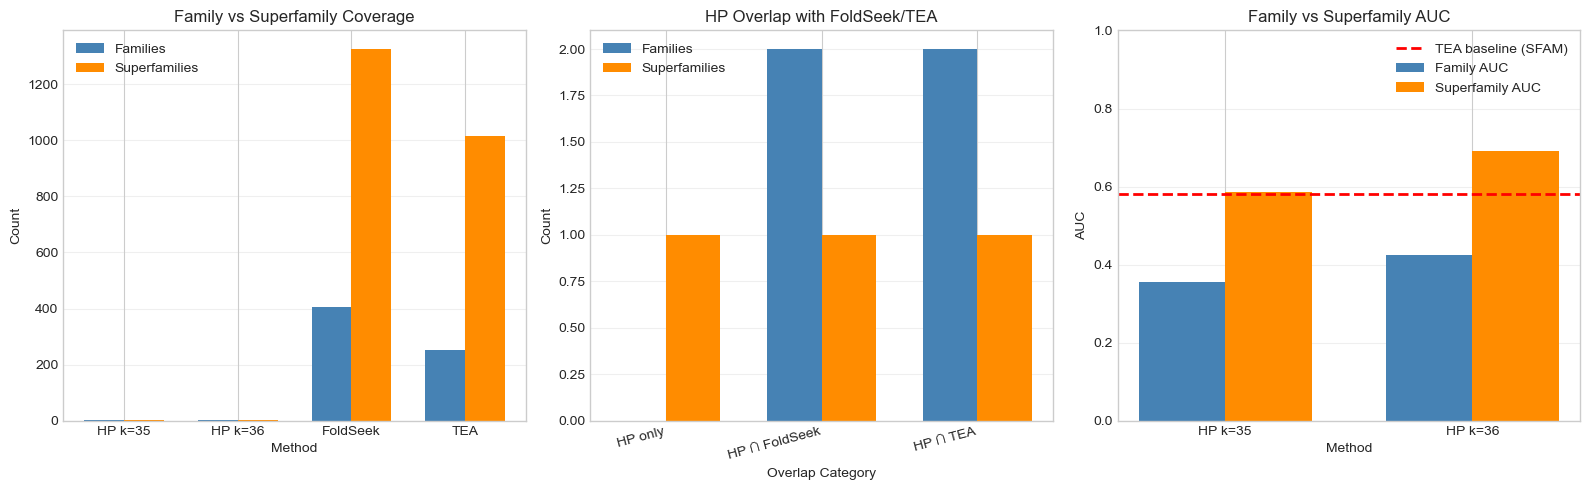

In [16]:
# Visualize Family vs Superfamily comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Coverage comparison (bar chart)
ax = axes[0]
methods = ["HP k=35", "HP k=36", "FoldSeek", "TEA"]
fam_counts = [len(hp_k35_fams), len(hp_k36_fams), len(foldseek_fams), len(tea_fams)]
sfam_counts = [
    len(hp_k35_sfams),
    len(hp_k36_sfams),
    len(foldseek_sfams),
    len(tea_sfams),
]

x = np.arange(len(methods))
width = 0.35
ax.bar(x - width / 2, fam_counts, width, label="Families", color="steelblue")
ax.bar(x + width / 2, sfam_counts, width, label="Superfamilies", color="darkorange")
ax.set_xlabel("Method")
ax.set_ylabel("Count")
ax.set_title("Family vs Superfamily Coverage")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Plot 2: Overlap Venn-style (simplified as grouped bar)
ax = axes[1]
overlap_data = {
    "HP only": [len(hp_unique_fams), len(hp_unique_sfams)],
    "HP ∩ FoldSeek": [len(hp_foldseek_fam_overlap), len(hp_foldseek_sfam_overlap)],
    "HP ∩ TEA": [len(hp_tea_fam_overlap), len(hp_tea_sfam_overlap)],
}
categories = list(overlap_data.keys())
fam_vals = [overlap_data[c][0] for c in categories]
sfam_vals = [overlap_data[c][1] for c in categories]

x = np.arange(len(categories))
ax.bar(x - width / 2, fam_vals, width, label="Families", color="steelblue")
ax.bar(x + width / 2, sfam_vals, width, label="Superfamilies", color="darkorange")
ax.set_xlabel("Overlap Category")
ax.set_ylabel("Count")
ax.set_title("HP Overlap with FoldSeek/TEA")
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=15, ha="right")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Plot 3: AUC comparison
ax = axes[2]
methods_auc = ["HP k=35", "HP k=36"]
fam_aucs = [hp_aucs["k35"]["fam"], hp_aucs["k36"]["fam"]]
sfam_aucs = [hp_aucs["k35"]["sfam"], hp_aucs["k36"]["sfam"]]

x = np.arange(len(methods_auc))
ax.bar(x - width / 2, fam_aucs, width, label="Family AUC", color="steelblue")
ax.bar(x + width / 2, sfam_aucs, width, label="Superfamily AUC", color="darkorange")
ax.axhline(
    y=0.58, color="red", linestyle="--", linewidth=2, label="TEA baseline (SFAM)"
)
ax.set_xlabel("Method")
ax.set_ylabel("AUC")
ax.set_title("Family vs Superfamily AUC")
ax.set_xticks(x)
ax.set_xticklabels(methods_auc)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("hp_k35_k36_fam_vs_sfam_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 5b. Detailed Superfamily Analysis

Analyze which superfamilies HP excels at compared to FoldSeek/TEA.

In [17]:
# Compute sensitivity for each superfamily in HP k=35 and k=36
def compute_sfam_sensitivity(rocx_df):
    """Compute sensitivity metrics for each superfamily."""
    sfam_stats = []
    for sfam in rocx_df["SFAM"].unique().to_list():
        sfam_data = rocx_df.filter(pl.col("SFAM") == sfam)
        n_queries = len(sfam_data)

        # Count matches at different levels
        n_fam_matches = sfam_data.filter(pl.col("FAM") > 0).shape[0]
        n_sfam_matches = sfam_data.filter(pl.col("SFAM") > 0).shape[
            0
        ]  # Should equal n_queries
        n_fold_matches = sfam_data.filter(pl.col("FOLD") > 0).shape[0]

        # Average counts
        avg_famcnt = sfam_data["FAMCNT"].mean()
        avg_sfamcnt = sfam_data["SFAMCNT"].mean()

        sfam_stats.append(
            {
                "SFAM": sfam,
                "n_queries": n_queries,
                "n_fam_matches": n_fam_matches,
                "n_sfam_matches": n_sfam_matches,
                "n_fold_matches": n_fold_matches,
                "fam_match_rate": n_fam_matches / n_queries if n_queries > 0 else 0,
                "avg_famcnt": avg_famcnt,
                "avg_sfamcnt": avg_sfamcnt,
            }
        )

    return pl.DataFrame(sfam_stats).sort("n_queries", descending=True)


hp_k35_sfam_stats = compute_sfam_sensitivity(hp_k35_rocx)
hp_k36_sfam_stats = compute_sfam_sensitivity(hp_k36_rocx)

print("HP k=35 superfamily statistics:")
print(hp_k35_sfam_stats.head(15))

HP k=35 superfamily statistics:
shape: (2, 8)
┌──────┬───────────┬─────────────┬─────────────┬────────────┬────────────┬────────────┬────────────┐
│ SFAM ┆ n_queries ┆ n_fam_match ┆ n_sfam_matc ┆ n_fold_mat ┆ fam_match_ ┆ avg_famcnt ┆ avg_sfamcn │
│ ---  ┆ ---       ┆ es          ┆ hes         ┆ ches       ┆ rate       ┆ ---        ┆ t          │
│ f64  ┆ i64       ┆ ---         ┆ ---         ┆ ---        ┆ ---        ┆ f64        ┆ ---        │
│      ┆           ┆ i64         ┆ i64         ┆ i64        ┆ f64        ┆            ┆ f64        │
╞══════╪═══════════╪═════════════╪═════════════╪════════════╪════════════╪════════════╪════════════╡
│ 1.0  ┆ 125       ┆ 76          ┆ 125         ┆ 125        ┆ 0.608      ┆ 1.328      ┆ 2.112      │
│ 0.0  ┆ 87        ┆ 0           ┆ 0           ┆ 4          ┆ 0.0        ┆ 0.0        ┆ 0.0        │
└──────┴───────────┴─────────────┴─────────────┴────────────┴────────────┴────────────┴────────────┘


In [18]:
print("HP k=36 superfamily statistics:")
print(hp_k36_sfam_stats.head(15))

HP k=36 superfamily statistics:
shape: (2, 8)
┌──────┬───────────┬─────────────┬─────────────┬────────────┬────────────┬────────────┬────────────┐
│ SFAM ┆ n_queries ┆ n_fam_match ┆ n_sfam_matc ┆ n_fold_mat ┆ fam_match_ ┆ avg_famcnt ┆ avg_sfamcn │
│ ---  ┆ ---       ┆ es          ┆ hes         ┆ ches       ┆ rate       ┆ ---        ┆ t          │
│ f64  ┆ i64       ┆ ---         ┆ ---         ┆ ---        ┆ ---        ┆ f64        ┆ ---        │
│      ┆           ┆ i64         ┆ i64         ┆ i64        ┆ f64        ┆            ┆ f64        │
╞══════╪═══════════╪═════════════╪═════════════╪════════════╪════════════╪════════════╪════════════╡
│ 1.0  ┆ 89        ┆ 55          ┆ 89          ┆ 89         ┆ 0.617978   ┆ 1.370787   ┆ 2.134831   │
│ 0.0  ┆ 39        ┆ 0           ┆ 0           ┆ 2          ┆ 0.0        ┆ 0.0        ┆ 0.0        │
└──────┴───────────┴─────────────┴─────────────┴────────────┴────────────┴────────────┴────────────┘


In [19]:
# Compare superfamily performance: HP vs FoldSeek vs TEA
# For each superfamily, compute family match rate


def compute_sfam_fam_rate(rocx_df, method_name):
    """Compute family match rate per superfamily."""
    results = []
    for sfam in rocx_df["SFAM"].unique().to_list():
        sfam_data = rocx_df.filter(pl.col("SFAM") == sfam)
        n_queries = len(sfam_data)
        n_fam = sfam_data.filter(pl.col("FAM") > 0).shape[0]
        results.append(
            {
                "SFAM": sfam,
                "queries": n_queries,
                "fam_rate": n_fam / n_queries if n_queries > 0 else 0,
            }
        )
    return pl.DataFrame(results)


hp_k35_rates = compute_sfam_fam_rate(hp_k35_rocx, "HP_k35")
hp_k36_rates = compute_sfam_fam_rate(hp_k36_rocx, "HP_k36")
foldseek_rates = compute_sfam_fam_rate(foldseek, "FoldSeek")
tea_rates = compute_sfam_fam_rate(tea_all, "TEA")

# Rename columns before joining to avoid conflicts
hp_k35_rates = hp_k35_rates.rename(
    {"queries": "HP_k35_queries", "fam_rate": "HP_k35_fam_rate"}
)
hp_k36_rates = hp_k36_rates.rename(
    {"queries": "HP_k36_queries", "fam_rate": "HP_k36_fam_rate"}
)
foldseek_rates = foldseek_rates.rename(
    {"queries": "FoldSeek_queries", "fam_rate": "FoldSeek_fam_rate"}
)
tea_rates = tea_rates.rename({"queries": "TEA_queries", "fam_rate": "TEA_fam_rate"})

# Merge all rates using full join
sfam_comparison = hp_k35_rates.join(hp_k36_rates, on="SFAM", how="full", coalesce=True)
sfam_comparison = sfam_comparison.join(
    foldseek_rates, on="SFAM", how="full", coalesce=True
)
sfam_comparison = sfam_comparison.join(tea_rates, on="SFAM", how="full", coalesce=True)

# Fill nulls with 0
sfam_comparison = sfam_comparison.fill_null(0)

print(f"Total superfamilies in comparison: {len(sfam_comparison)}")
sfam_comparison.head(10)

Total superfamilies in comparison: 1764


SFAM,HP_k35_queries,HP_k35_fam_rate,HP_k36_queries,HP_k36_fam_rate,FoldSeek_queries,FoldSeek_fam_rate,TEA_queries,TEA_fam_rate
f64,i64,f64,i64,f64,i64,f64,i64,f64
0.0,87,0.0,39,0.0,292,0.729452,523,0.489484
0.008065,0,0.0,0,0.0,1,1.0,1,1.0
0.008696,0,0.0,0,0.0,1,0.0,0,0.0
0.009009,0,0.0,0,0.0,2,1.0,0,0.0
0.009259,0,0.0,0,0.0,1,0.0,3,0.666667
0.010989,0,0.0,0,0.0,5,1.0,2,0.0
0.011236,0,0.0,0,0.0,2,0.5,3,1.0
0.0114943,0,0.0,0,0.0,6,1.0,5,0.8
0.0123457,0,0.0,0,0.0,5,1.0,8,1.0


In [20]:
# Find superfamilies where HP has higher family match rate than FoldSeek/TEA
hp_better_sfams = sfam_comparison.filter(
    (
        (pl.col("HP_k35_fam_rate") > pl.col("FoldSeek_fam_rate"))
        | (pl.col("HP_k36_fam_rate") > pl.col("FoldSeek_fam_rate"))
    )
    & ((pl.col("HP_k35_queries") > 0) | (pl.col("HP_k36_queries") > 0))
).sort("HP_k35_fam_rate", descending=True)

print(
    f"\nSuperfamilies where HP has higher family match rate than FoldSeek: {len(hp_better_sfams)}"
)
print("\nTop 15:")
print(hp_better_sfams.head(15))


Superfamilies where HP has higher family match rate than FoldSeek: 1

Top 15:
shape: (1, 9)
┌──────┬────────────┬────────────┬────────────┬───┬────────────┬───────────┬───────────┬───────────┐
│ SFAM ┆ HP_k35_que ┆ HP_k35_fam ┆ HP_k36_que ┆ … ┆ FoldSeek_q ┆ FoldSeek_ ┆ TEA_queri ┆ TEA_fam_r │
│ ---  ┆ ries       ┆ _rate      ┆ ries       ┆   ┆ ueries     ┆ fam_rate  ┆ es        ┆ ate       │
│ f64  ┆ ---        ┆ ---        ┆ ---        ┆   ┆ ---        ┆ ---       ┆ ---       ┆ ---       │
│      ┆ i64        ┆ f64        ┆ i64        ┆   ┆ i64        ┆ f64       ┆ i64       ┆ f64       │
╞══════╪════════════╪════════════╪════════════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
│ 1.0  ┆ 125        ┆ 0.608      ┆ 89         ┆ … ┆ 0          ┆ 0.0       ┆ 0         ┆ 0.0       │
└──────┴────────────┴────────────┴────────────┴───┴────────────┴───────────┴───────────┴───────────┘


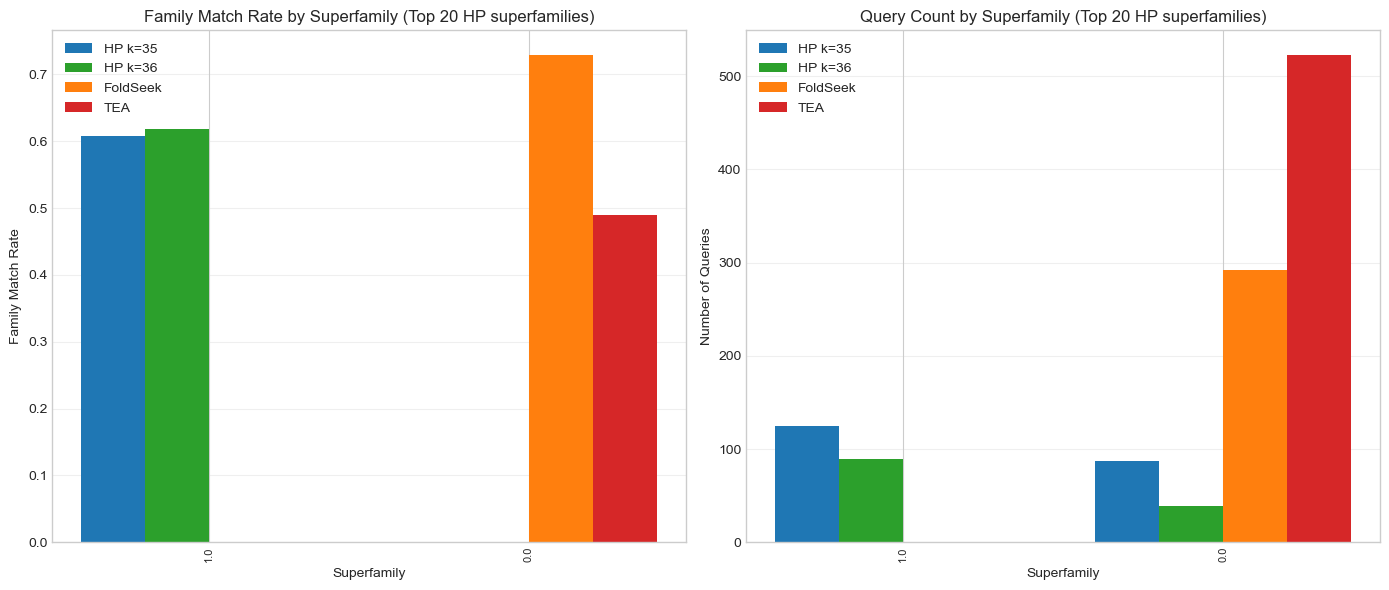

In [21]:
# Visualize superfamily performance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Get superfamilies present in HP
hp_sfams_list = (
    sfam_comparison.filter(
        (pl.col("HP_k35_queries") > 0) | (pl.col("HP_k36_queries") > 0)
    )
    .sort("HP_k35_queries", descending=True)["SFAM"]
    .to_list()[:20]
)

# Plot 1: Family match rate comparison for top HP superfamilies
ax = axes[0]
x = np.arange(len(hp_sfams_list))
width = 0.2

hp_k35_vals = [
    sfam_comparison.filter(pl.col("SFAM") == s)["HP_k35_fam_rate"][0]
    for s in hp_sfams_list
]
hp_k36_vals = [
    sfam_comparison.filter(pl.col("SFAM") == s)["HP_k36_fam_rate"][0]
    for s in hp_sfams_list
]
fs_vals = [
    sfam_comparison.filter(pl.col("SFAM") == s)["FoldSeek_fam_rate"][0]
    for s in hp_sfams_list
]
tea_vals = [
    sfam_comparison.filter(pl.col("SFAM") == s)["TEA_fam_rate"][0]
    for s in hp_sfams_list
]

ax.bar(x - 1.5 * width, hp_k35_vals, width, label="HP k=35", color="#1f77b4")
ax.bar(x - 0.5 * width, hp_k36_vals, width, label="HP k=36", color="#2ca02c")
ax.bar(x + 0.5 * width, fs_vals, width, label="FoldSeek", color="#ff7f0e")
ax.bar(x + 1.5 * width, tea_vals, width, label="TEA", color="#d62728")

ax.set_xlabel("Superfamily")
ax.set_ylabel("Family Match Rate")
ax.set_title("Family Match Rate by Superfamily (Top 20 HP superfamilies)")
ax.set_xticks(x)
ax.set_xticklabels(hp_sfams_list, rotation=90, fontsize=8)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Plot 2: Query count comparison
ax = axes[1]
hp_k35_counts = [
    sfam_comparison.filter(pl.col("SFAM") == s)["HP_k35_queries"][0]
    for s in hp_sfams_list
]
hp_k36_counts = [
    sfam_comparison.filter(pl.col("SFAM") == s)["HP_k36_queries"][0]
    for s in hp_sfams_list
]
fs_counts = [
    sfam_comparison.filter(pl.col("SFAM") == s)["FoldSeek_queries"][0]
    for s in hp_sfams_list
]
tea_counts = [
    sfam_comparison.filter(pl.col("SFAM") == s)["TEA_queries"][0] for s in hp_sfams_list
]

ax.bar(x - 1.5 * width, hp_k35_counts, width, label="HP k=35", color="#1f77b4")
ax.bar(x - 0.5 * width, hp_k36_counts, width, label="HP k=36", color="#2ca02c")
ax.bar(x + 0.5 * width, fs_counts, width, label="FoldSeek", color="#ff7f0e")
ax.bar(x + 1.5 * width, tea_counts, width, label="TEA", color="#d62728")

ax.set_xlabel("Superfamily")
ax.set_ylabel("Number of Queries")
ax.set_title("Query Count by Superfamily (Top 20 HP superfamilies)")
ax.set_xticks(x)
ax.set_xticklabels(hp_sfams_list, rotation=90, fontsize=8)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("hp_k35_k36_superfamily_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
# Analyze superfamily characteristics - what makes HP good at certain superfamilies?
# Look at superfamilies where HP performs well

print("\n" + "=" * 80)
print("SUPERFAMILY ANALYSIS SUMMARY")
print("=" * 80)

# Superfamilies where HP has 100% family match rate
perfect_sfams_k35 = hp_k35_sfam_stats.filter(pl.col("fam_match_rate") == 1.0)
perfect_sfams_k36 = hp_k36_sfam_stats.filter(pl.col("fam_match_rate") == 1.0)

print(f"\nSuperfamilies with 100% family match rate:")
print(f"  HP k=35: {len(perfect_sfams_k35)} superfamilies")
print(f"  HP k=36: {len(perfect_sfams_k36)} superfamilies")

# High-performing superfamilies (>= 80% family match rate)
high_perf_k35 = hp_k35_sfam_stats.filter(pl.col("fam_match_rate") >= 0.8)
high_perf_k36 = hp_k36_sfam_stats.filter(pl.col("fam_match_rate") >= 0.8)

print(f"\nSuperfamilies with >= 80% family match rate:")
print(f"  HP k=35: {len(high_perf_k35)} superfamilies")
print(f"  HP k=36: {len(high_perf_k36)} superfamilies")

# Show the high-performing superfamilies
print("\nHigh-performing HP k=35 superfamilies (>= 80% family match rate):")
print(high_perf_k35.select(["SFAM", "n_queries", "fam_match_rate", "avg_famcnt"]))


SUPERFAMILY ANALYSIS SUMMARY

Superfamilies with 100% family match rate:
  HP k=35: 0 superfamilies
  HP k=36: 0 superfamilies

Superfamilies with >= 80% family match rate:
  HP k=35: 0 superfamilies
  HP k=36: 0 superfamilies

High-performing HP k=35 superfamilies (>= 80% family match rate):
shape: (0, 4)
┌──────┬───────────┬────────────────┬────────────┐
│ SFAM ┆ n_queries ┆ fam_match_rate ┆ avg_famcnt │
│ ---  ┆ ---       ┆ ---            ┆ ---        │
│ f64  ┆ i64       ┆ f64            ┆ f64        │
╞══════╪═══════════╪════════════════╪════════════╡
└──────┴───────────┴────────────────┴────────────┘


In [23]:
# Save superfamily comparison
sfam_comparison.write_csv("hp_k35_k36_superfamily_detailed_comparison.csv")
print(
    "Saved detailed superfamily comparison to hp_k35_k36_superfamily_detailed_comparison.csv"
)

hp_k35_sfam_stats.write_csv("hp_k35_superfamily_stats.csv")
hp_k36_sfam_stats.write_csv("hp_k36_superfamily_stats.csv")
print("Saved HP k=35 superfamily stats to hp_k35_superfamily_stats.csv")
print("Saved HP k=36 superfamily stats to hp_k36_superfamily_stats.csv")

Saved detailed superfamily comparison to hp_k35_k36_superfamily_detailed_comparison.csv
Saved HP k=35 superfamily stats to hp_k35_superfamily_stats.csv
Saved HP k=36 superfamily stats to hp_k36_superfamily_stats.csv


## 6. Query-Level Overlap Analysis

In [24]:
# Compare at query level (NAME column)
hp_k35_queries = set(hp_k35_rocx["NAME"].unique().to_list())
hp_k36_queries = set(hp_k36_rocx["NAME"].unique().to_list())
foldseek_queries = set(foldseek["NAME"].unique().to_list())
tea_queries = set(tea_all["NAME"].unique().to_list())

print("Query-level statistics:")
print(f"  HP k=35 queries: {len(hp_k35_queries)}")
print(f"  HP k=36 queries: {len(hp_k36_queries)}")
print(f"  FoldSeek queries: {len(foldseek_queries)}")
print(f"  TEA queries: {len(tea_queries)}")

Query-level statistics:
  HP k=35 queries: 212
  HP k=36 queries: 128
  FoldSeek queries: 5713
  TEA queries: 5737


In [25]:
# Query overlap
print("\nQuery Overlap:")
print("=" * 60)

# k=35 vs k=36
k35_k36_query_overlap = hp_k35_queries & hp_k36_queries
print(f"\nHP k=35 ∩ HP k=36: {len(k35_k36_query_overlap)} queries")
print(f"  Only in k=35: {len(hp_k35_queries - hp_k36_queries)}")
print(f"  Only in k=36: {len(hp_k36_queries - hp_k35_queries)}")

# HP combined
hp_combined_queries = hp_k35_queries | hp_k36_queries
print(f"\nHP combined (k=35 or k=36): {len(hp_combined_queries)} unique queries")

# HP vs FoldSeek
hp_foldseek_query_overlap = hp_combined_queries & foldseek_queries
print(f"\nHP ∩ FoldSeek: {len(hp_foldseek_query_overlap)} queries")
print(f"  Only in HP: {len(hp_combined_queries - foldseek_queries)}")
print(f"  Only in FoldSeek: {len(foldseek_queries - hp_combined_queries)}")

# HP vs TEA
hp_tea_query_overlap = hp_combined_queries & tea_queries
print(f"\nHP ∩ TEA: {len(hp_tea_query_overlap)} queries")
print(f"  Only in HP: {len(hp_combined_queries - tea_queries)}")
print(f"  Only in TEA: {len(tea_queries - hp_combined_queries)}")


Query Overlap:

HP k=35 ∩ HP k=36: 128 queries
  Only in k=35: 84
  Only in k=36: 0

HP combined (k=35 or k=36): 212 unique queries

HP ∩ FoldSeek: 57 queries
  Only in HP: 155
  Only in FoldSeek: 5656

HP ∩ TEA: 57 queries
  Only in HP: 155
  Only in TEA: 5680


In [26]:
# Queries unique to HP (not in FoldSeek or TEA)
hp_unique_queries_set = hp_combined_queries - (foldseek_queries | tea_queries)
print(f"\nQueries UNIQUE to HP (not in FoldSeek or TEA): {len(hp_unique_queries_set)}")

# Get details of unique queries
unique_query_details = []
for query in hp_unique_queries_set:
    # Check if in k=35 or k=36
    in_k35 = query in hp_k35_queries
    in_k36 = query in hp_k36_queries

    # Get SFAM from whichever has it
    if in_k35:
        sfam = hp_k35_rocx.filter(pl.col("NAME") == query)["SFAM"][0]
    else:
        sfam = hp_k36_rocx.filter(pl.col("NAME") == query)["SFAM"][0]

    unique_query_details.append(
        {"NAME": query, "SFAM": sfam, "in_k35": in_k35, "in_k36": in_k36}
    )

unique_queries_df = pl.DataFrame(unique_query_details)
print("\nUnique HP queries by superfamily:")
print(
    unique_queries_df.group_by("SFAM")
    .agg(pl.len().alias("n_queries"))
    .sort("n_queries", descending=True)
)


Queries UNIQUE to HP (not in FoldSeek or TEA): 155

Unique HP queries by superfamily:
shape: (2, 2)
┌──────┬───────────┐
│ SFAM ┆ n_queries │
│ ---  ┆ ---       │
│ f64  ┆ u32       │
╞══════╪═══════════╡
│ 1.0  ┆ 93        │
│ 0.0  ┆ 62        │
└──────┴───────────┘


## 7. Analyze SCOPe Class Distribution

In [27]:
# Extract class from SCOP column (first letter, e.g., 'a', 'b', 'c', etc.)
def extract_class(scop):
    if scop and len(scop) > 0:
        return scop[0]
    return "unknown"


# Add class to each dataset
hp_k35_rocx_class = hp_k35_rocx.with_columns(
    pl.col("SCOP").map_elements(extract_class, return_dtype=pl.Utf8).alias("CLASS")
)
hp_k36_rocx_class = hp_k36_rocx.with_columns(
    pl.col("SCOP").map_elements(extract_class, return_dtype=pl.Utf8).alias("CLASS")
)
foldseek_class = foldseek.with_columns(
    pl.col("SCOP").map_elements(extract_class, return_dtype=pl.Utf8).alias("CLASS")
)
tea_class = tea_all.with_columns(
    pl.col("SCOP").map_elements(extract_class, return_dtype=pl.Utf8).alias("CLASS")
)

# Count by class
print("Query distribution by SCOPe class:")
print("\nHP k=35:")
print(hp_k35_rocx_class.group_by("CLASS").agg(pl.len().alias("n")).sort("CLASS"))
print("\nHP k=36:")
print(hp_k36_rocx_class.group_by("CLASS").agg(pl.len().alias("n")).sort("CLASS"))
print("\nFoldSeek:")
print(foldseek_class.group_by("CLASS").agg(pl.len().alias("n")).sort("CLASS"))
print("\nTEA:")
print(tea_class.group_by("CLASS").agg(pl.len().alias("n")).sort("CLASS"))

Query distribution by SCOPe class:

HP k=35:
shape: (6, 2)
┌───────┬─────┐
│ CLASS ┆ n   │
│ ---   ┆ --- │
│ str   ┆ u32 │
╞═══════╪═════╡
│ a     ┆ 26  │
│ b     ┆ 12  │
│ c     ┆ 109 │
│ d     ┆ 37  │
│ e     ┆ 11  │
│ f     ┆ 17  │
└───────┴─────┘

HP k=36:
shape: (6, 2)
┌───────┬─────┐
│ CLASS ┆ n   │
│ ---   ┆ --- │
│ str   ┆ u32 │
╞═══════╪═════╡
│ a     ┆ 11  │
│ b     ┆ 10  │
│ c     ┆ 69  │
│ d     ┆ 26  │
│ e     ┆ 5   │
│ f     ┆ 7   │
└───────┴─────┘

FoldSeek:
shape: (6, 2)
┌───────┬──────┐
│ CLASS ┆ n    │
│ ---   ┆ ---  │
│ str   ┆ u32  │
╞═══════╪══════╡
│ a     ┆ 1015 │
│ b     ┆ 1736 │
│ c     ┆ 1632 │
│ d     ┆ 1103 │
│ f     ┆ 69   │
│ g     ┆ 158  │
└───────┴──────┘

TEA:
shape: (6, 2)
┌───────┬──────┐
│ CLASS ┆ n    │
│ ---   ┆ ---  │
│ str   ┆ u32  │
╞═══════╪══════╡
│ a     ┆ 1018 │
│ b     ┆ 1748 │
│ c     ┆ 1635 │
│ d     ┆ 1109 │
│ f     ┆ 69   │
│ g     ┆ 158  │
└───────┴──────┘


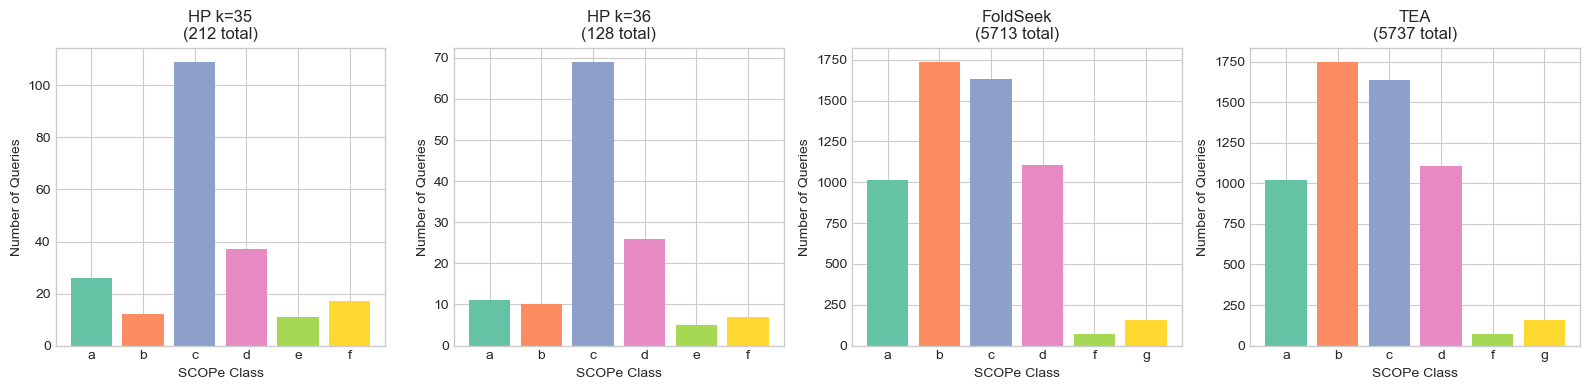

In [28]:
# Visualize class distribution
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

class_names = {
    "a": "All-alpha",
    "b": "All-beta",
    "c": "Alpha/beta",
    "d": "Alpha+beta",
    "e": "Multi-domain",
    "f": "Membrane",
    "g": "Small",
}

datasets = [
    (hp_k35_rocx_class, "HP k=35"),
    (hp_k36_rocx_class, "HP k=36"),
    (foldseek_class, "FoldSeek"),
    (tea_class, "TEA"),
]

for ax, (df, title) in zip(axes, datasets):
    class_counts = df.group_by("CLASS").agg(pl.len().alias("n")).sort("CLASS")
    classes = class_counts["CLASS"].to_list()
    counts = class_counts["n"].to_list()

    colors = cm.Set2(range(len(classes)))
    ax.bar(classes, counts, color=colors)
    ax.set_xlabel("SCOPe Class")
    ax.set_ylabel("Number of Queries")
    ax.set_title(f"{title}\n({sum(counts)} total)")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("hp_k35_k36_class_distribution.pdf", dpi=300, bbox_inches="tight")
plt.show()

## 7b. SCOPe Domain Annotations

Load SCOPe domain annotations to get descriptions and sequence lengths for the superfamilies.

In [29]:
# Load SCOPe 40% identity threshold annotations
scope_th40_path = Path(
    "/Users/olga/code/2024-kmerseek-analysis/data/SCOPe/processed_at_th/th_40.tsv"
)
scope_annotations = pl.read_csv(scope_th40_path, separator="\t")

print(f"SCOPe annotations shape: {scope_annotations.shape}")
print(f"Columns: {scope_annotations.columns}")
scope_annotations.head()

SCOPe annotations shape: (14280, 10)
Columns: ['sid', 'span', 'sccs', 'cls_label', 'fold', 'superfamily', 'family', 'seq', 'description', 'seq_len']


sid,span,sccs,cls_label,fold,superfamily,family,seq,description,seq_len
str,str,str,str,str,str,str,str,str,i64
"""d1dlwa_""","""(A:)""","""a.1.1.1""","""a""","""a.1""","""a.1.1""","""a.1.1.1""","""SLFEQLGGQAAVQAVTAQFYANIQADATVA…","""Protozoan/bacterial hemoglobin…",116
"""d2gkma_""","""(A:)""","""a.1.1.1""","""a""","""a.1""","""a.1.1""","""a.1.1.1""","""GLLSRLRKREPISIYDKIGGHEAIEVVVED…","""Protozoan/bacterial hemoglobin…",127
"""d1ngka_""","""(A:)""","""a.1.1.1""","""a""","""a.1""","""a.1.1""","""a.1.1.1""","""KSFYDAVGGAKTFDAIVSRFYAQVAEDEVL…","""Protozoan/bacterial hemoglobin…",126
"""d2bkma_""","""(A:)""","""a.1.1.1""","""a""","""a.1""","""a.1.1""","""a.1.1.1""","""EQWQTLYEAIGGEETVAKLVEAFYRRVAAH…","""automated matches {Geobacillus…",128
"""d4i0va_""","""(A:)""","""a.1.1.1""","""a""","""a.1""","""a.1.1""","""a.1.1.1""","""ASLYEKLGGAAAVDLAVEKFYGKVLADERV…","""automated matches {Synechococc…",123


In [30]:
# Get unique superfamilies and their characteristics
sfam_annotations = (
    scope_annotations.group_by("superfamily")
    .agg(
        [
            pl.len().alias("n_domains"),
            pl.col("seq_len").mean().alias("avg_seq_len"),
            pl.col("seq_len").min().alias("min_seq_len"),
            pl.col("seq_len").max().alias("max_seq_len"),
            pl.col("family").n_unique().alias("n_families"),
            pl.col("description").first().alias("example_description"),
        ]
    )
    .sort("n_domains", descending=True)
)

print(f"Total superfamilies in SCOPe 40: {len(sfam_annotations)}")
sfam_annotations.head(10)

Total superfamilies in SCOPe 40: 1998


superfamily,n_domains,avg_seq_len,min_seq_len,max_seq_len,n_families,example_description
str,u32,f64,i64,i64,u32,str
"""c.37.1""",333,238.813814,61,730,27,"""5' polynucleotide kinase-3' ph…"
"""a.4.5""",252,102.396825,25,194,81,"""Biotin repressor, N-terminal d…"
"""b.1.1""",239,104.188285,72,251,5,"""Alphaherpesvirus glycoprotein …"
"""c.47.1""",215,124.595349,71,240,24,"""Bacterocin transport accessory…"
"""c.94.1""",187,304.481283,136,537,4,"""ABC transporter, periplasmic s…"
"""c.66.1""",157,266.407643,171,524,58,"""Catechol O-methyltransferase, …"
"""c.69.1""",152,298.434211,122,579,42,"""Acetylcholinesterase {Fruit fl…"
"""c.67.1""",143,396.146853,322,494,10,"""AAT homologue TM1698 {Thermoto…"
"""d.144.1""",130,301.038462,192,436,8,"""Actin-fragmin kinase, catalyti…"


In [31]:
# Annotate HP superfamilies with SCOPe information
# First, we need to map our SFAM column to the SCOPe superfamily format

# HP ROCX uses numeric SFAM, but we need to get the string superfamily from the SCOP column
# Extract superfamily string from SCOP column (e.g., 'a.1.1.1' -> 'a.1.1')


def get_sfam_string(scop):
    """Extract superfamily from SCOP classification (e.g., a.1.1.1 -> a.1.1)"""
    if scop and "." in scop:
        parts = scop.split(".")
        if len(parts) >= 3:
            return ".".join(parts[:3])
    return None


# Add superfamily string to HP ROCX data
hp_k35_annotated = hp_k35_rocx.with_columns(
    pl.col("SCOP")
    .map_elements(get_sfam_string, return_dtype=pl.Utf8)
    .alias("sfam_string")
)
hp_k36_annotated = hp_k36_rocx.with_columns(
    pl.col("SCOP")
    .map_elements(get_sfam_string, return_dtype=pl.Utf8)
    .alias("sfam_string")
)

print("HP k=35 superfamily strings:")
print(hp_k35_annotated.select(["NAME", "SCOP", "sfam_string"]).head(10))

HP k=35 superfamily strings:
shape: (10, 3)
┌─────────┬───────────┬─────────────┐
│ NAME    ┆ SCOP      ┆ sfam_string │
│ ---     ┆ ---       ┆ ---         │
│ str     ┆ str       ┆ str         │
╞═════════╪═══════════╪═════════════╡
│ d6xexa1 ┆ c.2.1.0   ┆ c.2.1       │
│ d2etva1 ┆ c.92.2.4  ┆ c.92.2      │
│ g1qhh.1 ┆ c.37.1.19 ┆ c.37.1      │
│ d1wtja_ ┆ c.122.1.0 ┆ c.122.1     │
│ d5wm2a1 ┆ e.23.1.0  ┆ e.23.1      │
│ d2dtea1 ┆ c.2.1.0   ┆ c.2.1       │
│ d1agja_ ┆ b.47.1.1  ┆ b.47.1      │
│ d5o3za_ ┆ c.2.1.0   ┆ c.2.1       │
│ d3mlba_ ┆ c.26.1.3  ┆ c.26.1      │
│ d3e96a_ ┆ c.1.10.0  ┆ c.1.10      │
└─────────┴───────────┴─────────────┘


In [32]:
# Join HP data with SCOPe annotations
hp_k35_with_annot = hp_k35_annotated.join(
    sfam_annotations.rename({"superfamily": "sfam_string"}),
    on="sfam_string",
    how="left",
)

hp_k36_with_annot = hp_k36_annotated.join(
    sfam_annotations.rename({"superfamily": "sfam_string"}),
    on="sfam_string",
    how="left",
)

print("HP k=35 with annotations:")
print(
    hp_k35_with_annot.select(
        [
            "NAME",
            "sfam_string",
            "n_domains",
            "n_families",
            "avg_seq_len",
            "example_description",
        ]
    ).head(10)
)

HP k=35 with annotations:
shape: (10, 6)
┌─────────┬─────────────┬───────────┬────────────┬─────────────┬─────────────────────────────────┐
│ NAME    ┆ sfam_string ┆ n_domains ┆ n_families ┆ avg_seq_len ┆ example_description             │
│ ---     ┆ ---         ┆ ---       ┆ ---        ┆ ---         ┆ ---                             │
│ str     ┆ str         ┆ u32       ┆ u32        ┆ f64         ┆ str                             │
╞═════════╪═════════════╪═══════════╪════════════╪═════════════╪═════════════════════════════════╡
│ d6xexa1 ┆ c.2.1       ┆ null      ┆ null       ┆ null        ┆ null                            │
│ d2etva1 ┆ c.92.2      ┆ 38        ┆ 5          ┆ 302.605263  ┆ Periplasmic ferric siderophore… │
│ g1qhh.1 ┆ c.37.1      ┆ 333       ┆ 27         ┆ 238.813814  ┆ 5' polynucleotide kinase-3' ph… │
│ d1wtja_ ┆ c.122.1     ┆ 9         ┆ 2          ┆ 344.888889  ┆ 2,3-diketogulonate oxidoreduct… │
│ d5wm2a1 ┆ e.23.1      ┆ 26        ┆ 2          ┆ 513.769231  ┆ 4-c

In [33]:
# Analyze characteristics of superfamilies where HP performs well
print("\n" + "=" * 80)
print("SUPERFAMILY CHARACTERISTICS IN HP RESULTS")
print("=" * 80)

# Summary of HP superfamilies
hp_k35_sfam_summary = (
    hp_k35_with_annot.group_by("sfam_string")
    .agg(
        [
            pl.len().alias("hp_queries"),
            pl.col("n_domains").first().alias("scope_domains"),
            pl.col("n_families").first().alias("scope_families"),
            pl.col("avg_seq_len").first().alias("avg_seq_len"),
            pl.col("example_description").first().alias("description"),
        ]
    )
    .sort("hp_queries", descending=True)
)

print("\nTop 20 superfamilies in HP k=35 with annotations:")
print(hp_k35_sfam_summary.head(20))


SUPERFAMILY CHARACTERISTICS IN HP RESULTS

Top 20 superfamilies in HP k=35 with annotations:
shape: (20, 6)
┌─────────────┬────────────┬───────────────┬────────────────┬─────────────┬────────────────────────┐
│ sfam_string ┆ hp_queries ┆ scope_domains ┆ scope_families ┆ avg_seq_len ┆ description            │
│ ---         ┆ ---        ┆ ---           ┆ ---            ┆ ---         ┆ ---                    │
│ str         ┆ u32        ┆ u32           ┆ u32            ┆ f64         ┆ str                    │
╞═════════════╪════════════╪═══════════════╪════════════════╪═════════════╪════════════════════════╡
│ c.2.1       ┆ 12         ┆ null          ┆ null           ┆ null        ┆ null                   │
│ c.37.1      ┆ 12         ┆ 333           ┆ 27             ┆ 238.813814  ┆ 5' polynucleotide      │
│             ┆            ┆               ┆                ┆             ┆ kinase-3' ph…          │
│ d.144.1     ┆ 12         ┆ 130           ┆ 8              ┆ 301.038462  ┆ Actin-f

In [34]:
# Compare sequence lengths: HP superfamilies vs all SCOPe superfamilies
hp_sfams = set(hp_k35_with_annot["sfam_string"].unique().to_list()) | set(
    hp_k36_with_annot["sfam_string"].unique().to_list()
)
hp_sfams = [s for s in hp_sfams if s is not None]

hp_avg_len = sfam_annotations.filter(pl.col("superfamily").is_in(hp_sfams))[
    "avg_seq_len"
].mean()
all_avg_len = sfam_annotations["avg_seq_len"].mean()

print(f"\nSequence Length Comparison:")
print(f"  HP superfamilies average length: {hp_avg_len:.1f} residues")
print(f"  All SCOPe superfamilies average length: {all_avg_len:.1f} residues")

# Number of families per superfamily
hp_avg_fam = sfam_annotations.filter(pl.col("superfamily").is_in(hp_sfams))[
    "n_families"
].mean()
all_avg_fam = sfam_annotations["n_families"].mean()

print(f"\nFamily Diversity:")
print(f"  HP superfamilies avg families: {hp_avg_fam:.1f}")
print(f"  All SCOPe superfamilies avg families: {all_avg_fam:.1f}")


Sequence Length Comparison:
  HP superfamilies average length: 282.4 residues
  All SCOPe superfamilies average length: 157.7 residues

Family Diversity:
  HP superfamilies avg families: 7.7
  All SCOPe superfamilies avg families: 2.3


Mean sequence lengths:
  All SCOPe:   157.7 residues
  FoldSeek:    156.7 residues
  TEA:         156.5 residues
  HP k=35/k=36: 282.4 residues

Mean families per superfamily:
  All SCOPe:   2.3
  FoldSeek:    4.6
  TEA:         4.6
  HP k=35/k=36: 7.7


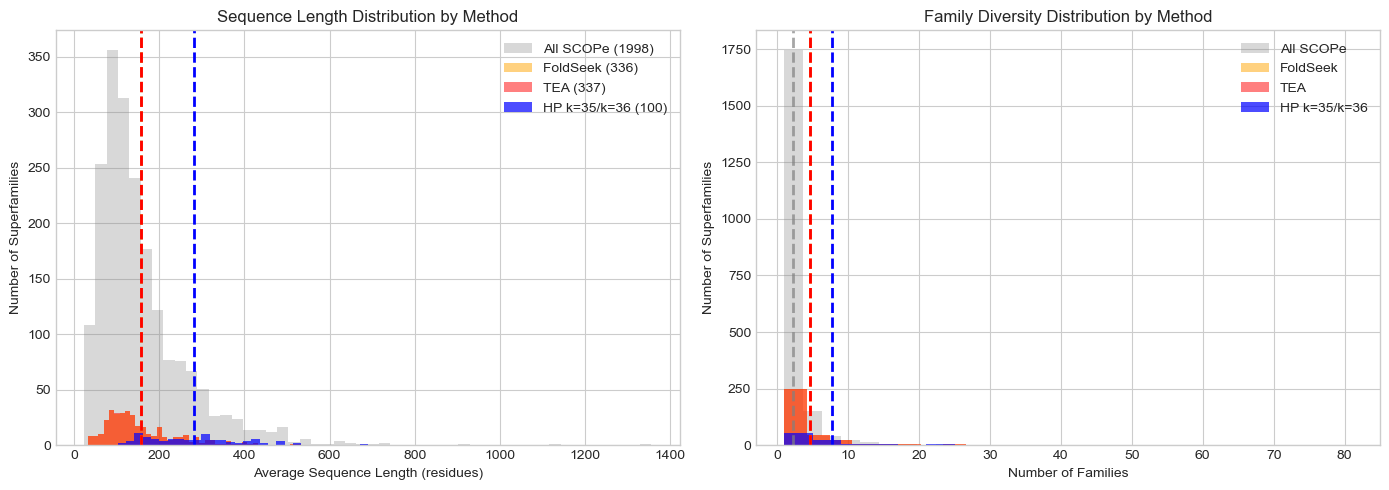

In [35]:
# Visualize sequence length distribution - HP vs FoldSeek vs TEA vs All SCOPe

# Get superfamily strings for each method
foldseek_sfam_strings = set()
for row in foldseek.iter_rows(named=True):
    sfam_str = get_sfam_string(row["SCOP"])
    if sfam_str:
        foldseek_sfam_strings.add(sfam_str)

tea_sfam_strings = set()
for row in tea_all.iter_rows(named=True):
    sfam_str = get_sfam_string(row["SCOP"])
    if sfam_str:
        tea_sfam_strings.add(sfam_str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Sequence length distribution
ax = axes[0]
all_lens = sfam_annotations["avg_seq_len"].to_list()
hp_lens = sfam_annotations.filter(pl.col("superfamily").is_in(hp_sfams))[
    "avg_seq_len"
].to_list()
foldseek_lens = sfam_annotations.filter(
    pl.col("superfamily").is_in(list(foldseek_sfam_strings))
)["avg_seq_len"].to_list()
tea_lens = sfam_annotations.filter(pl.col("superfamily").is_in(list(tea_sfam_strings)))[
    "avg_seq_len"
].to_list()

ax.hist(
    all_lens, bins=50, alpha=0.3, label=f"All SCOPe ({len(all_lens)})", color="gray"
)
ax.hist(
    foldseek_lens,
    bins=40,
    alpha=0.5,
    label=f"FoldSeek ({len(foldseek_lens)})",
    color="orange",
)
ax.hist(tea_lens, bins=40, alpha=0.5, label=f"TEA ({len(tea_lens)})", color="red")
ax.hist(
    hp_lens, bins=30, alpha=0.7, label=f"HP k=35/k=36 ({len(hp_lens)})", color="blue"
)

ax.axvline(np.mean(all_lens), color="gray", linestyle="--", linewidth=2, alpha=0.7)
ax.axvline(np.mean(foldseek_lens), color="orange", linestyle="--", linewidth=2)
ax.axvline(np.mean(tea_lens), color="red", linestyle="--", linewidth=2)
ax.axvline(np.mean(hp_lens), color="blue", linestyle="--", linewidth=2)

ax.set_xlabel("Average Sequence Length (residues)")
ax.set_ylabel("Number of Superfamilies")
ax.set_title("Sequence Length Distribution by Method")
ax.legend()

# Print mean values
print("Mean sequence lengths:")
print(f"  All SCOPe:   {np.mean(all_lens):.1f} residues")
print(f"  FoldSeek:    {np.mean(foldseek_lens):.1f} residues")
print(f"  TEA:         {np.mean(tea_lens):.1f} residues")
print(f"  HP k=35/k=36: {np.mean(hp_lens):.1f} residues")

# Plot 2: Number of families per superfamily
ax = axes[1]
all_fams = sfam_annotations["n_families"].to_list()
hp_fams = sfam_annotations.filter(pl.col("superfamily").is_in(hp_sfams))[
    "n_families"
].to_list()
foldseek_fams_count = sfam_annotations.filter(
    pl.col("superfamily").is_in(list(foldseek_sfam_strings))
)["n_families"].to_list()
tea_fams_count = sfam_annotations.filter(
    pl.col("superfamily").is_in(list(tea_sfam_strings))
)["n_families"].to_list()

ax.hist(all_fams, bins=30, alpha=0.3, label=f"All SCOPe", color="gray")
ax.hist(foldseek_fams_count, bins=25, alpha=0.5, label=f"FoldSeek", color="orange")
ax.hist(tea_fams_count, bins=25, alpha=0.5, label=f"TEA", color="red")
ax.hist(hp_fams, bins=20, alpha=0.7, label=f"HP k=35/k=36", color="blue")

ax.axvline(np.mean(all_fams), color="gray", linestyle="--", linewidth=2, alpha=0.7)
ax.axvline(np.mean(foldseek_fams_count), color="orange", linestyle="--", linewidth=2)
ax.axvline(np.mean(tea_fams_count), color="red", linestyle="--", linewidth=2)
ax.axvline(np.mean(hp_fams), color="blue", linestyle="--", linewidth=2)

ax.set_xlabel("Number of Families")
ax.set_ylabel("Number of Superfamilies")
ax.set_title("Family Diversity Distribution by Method")
ax.legend()

# Print mean values
print("\nMean families per superfamily:")
print(f"  All SCOPe:   {np.mean(all_fams):.1f}")
print(f"  FoldSeek:    {np.mean(foldseek_fams_count):.1f}")
print(f"  TEA:         {np.mean(tea_fams_count):.1f}")
print(f"  HP k=35/k=36: {np.mean(hp_fams):.1f}")

plt.tight_layout()
plt.savefig("hp_k35_k36_scope_characteristics.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [36]:
# Save annotated results
hp_k35_sfam_summary.write_csv("hp_k35_superfamily_with_scope_annotations.csv")
print("Saved HP k=35 superfamily summary with SCOPe annotations")

Saved HP k=35 superfamily summary with SCOPe annotations


## 7b-2. SCOPe Identity Threshold Analysis

Compare HP superfamilies across different SCOPe sequence identity thresholds (10%, 20%, 25%, 30%, 35%, 40%).

In [37]:
# Load all SCOPe identity threshold files
scope_th_dir = Path(
    "/Users/olga/code/2024-kmerseek-analysis/data/SCOPe/processed_at_th"
)
thresholds = [10, 20, 25, 30, 35, 40]

scope_th_data = {}
for th in thresholds:
    th_file = scope_th_dir / f"th_{th}.tsv"
    if th_file.exists():
        df = pl.read_csv(th_file, separator="\t")
        scope_th_data[th] = df
        print(f"Loaded th_{th}.tsv: {len(df)} domains")
    else:
        print(f"File not found: {th_file}")

print(f"\nLoaded {len(scope_th_data)} threshold files")

Loaded th_10.tsv: 6784 domains
Loaded th_20.tsv: 7547 domains
Loaded th_25.tsv: 8617 domains
Loaded th_30.tsv: 10370 domains
Loaded th_35.tsv: 12346 domains
Loaded th_40.tsv: 14280 domains

Loaded 6 threshold files


In [38]:
# Analyze superfamily representation at each threshold
threshold_stats = []

for th, df in scope_th_data.items():
    n_domains = len(df)
    n_sfams = df["superfamily"].n_unique()
    n_fams = df["family"].n_unique()
    avg_len = df["seq_len"].mean()

    threshold_stats.append(
        {
            "threshold": th,
            "n_domains": n_domains,
            "n_superfamilies": n_sfams,
            "n_families": n_fams,
            "avg_seq_len": avg_len,
        }
    )

threshold_summary = pl.DataFrame(threshold_stats).sort("threshold")
print("SCOPe dataset summary by sequence identity threshold:")
threshold_summary

SCOPe dataset summary by sequence identity threshold:


threshold,n_domains,n_superfamilies,n_families,avg_seq_len
i64,i64,i64,i64,f64
10,6784,1985,3999,164.913915
20,7547,1995,4116,170.335498
25,8617,1996,4197,173.797609
30,10370,1997,4310,177.522276
35,12346,1997,4432,179.465252
40,14280,1998,4521,181.001611


In [39]:
# Check how HP families are represented at each threshold
# HP families (SCOP column contains full classification like 'a.1.1.1')
hp_fams = set(hp_k35_rocx["SCOP"].unique().to_list()) | set(
    hp_k36_rocx["SCOP"].unique().to_list()
)
hp_fams = set(s for s in hp_fams if s is not None)
hp_fam_strings = list(hp_fams)

hp_representation = []
for th, df in scope_th_data.items():
    scope_fams = set(df["family"].unique().to_list())

    # How many HP families are in this threshold?
    hp_in_scope = len([s for s in hp_fam_strings if s in scope_fams])

    # How many domains from HP families?
    hp_domains = df.filter(pl.col("family").is_in(hp_fam_strings))
    n_hp_domains = len(hp_domains)

    hp_representation.append(
        {
            "threshold": th,
            "hp_fams_represented": hp_in_scope,
            "total_fams": len(scope_fams),
            "hp_domains": n_hp_domains,
            "total_domains": len(df),
            "hp_domain_fraction": n_hp_domains / len(df) * 100,
        }
    )

hp_rep_df = pl.DataFrame(hp_representation).sort("threshold")
print("HP family representation at each SCOPe threshold:")
hp_rep_df

HP family representation at each SCOPe threshold:


threshold,hp_fams_represented,total_fams,hp_domains,total_domains,hp_domain_fraction
i64,i64,i64,i64,i64,f64
10,121,3999,440,6784,6.485849
20,123,4116,574,7547,7.605671
25,124,4197,781,8617,9.063479
30,127,4310,1205,10370,11.620058
35,129,4432,1677,12346,13.583347
40,130,4521,2130,14280,14.915966


In [40]:
# Analyze sequence characteristics at each threshold for HP vs non-HP families
comparison_by_threshold = []

for th, df in scope_th_data.items():
    # HP domains
    hp_domains = df.filter(pl.col("family").is_in(hp_fam_strings))
    # Non-HP domains
    non_hp_domains = df.filter(~pl.col("family").is_in(hp_fam_strings))

    if len(hp_domains) > 0 and len(non_hp_domains) > 0:
        comparison_by_threshold.append(
            {
                "threshold": th,
                "hp_n_domains": len(hp_domains),
                "hp_avg_len": hp_domains["seq_len"].mean(),
                "hp_min_len": hp_domains["seq_len"].min(),
                "hp_max_len": hp_domains["seq_len"].max(),
                "nonhp_n_domains": len(non_hp_domains),
                "nonhp_avg_len": non_hp_domains["seq_len"].mean(),
                "nonhp_min_len": non_hp_domains["seq_len"].min(),
                "nonhp_max_len": non_hp_domains["seq_len"].max(),
            }
        )

comparison_df = pl.DataFrame(comparison_by_threshold)
print("Sequence length comparison: HP families vs non-HP families")
comparison_df

Sequence length comparison: HP families vs non-HP families


threshold,hp_n_domains,hp_avg_len,hp_min_len,hp_max_len,nonhp_n_domains,nonhp_avg_len,nonhp_min_len,nonhp_max_len
i64,i64,f64,i64,i64,i64,f64,i64,i64
10,440,266.206818,51,1207,6344,157.888556,20,1500
20,574,272.799652,34,1207,6973,161.900903,20,1664
25,781,272.699104,34,1207,7836,163.940276,20,1664
30,1205,273.306224,34,1207,9165,164.928751,20,1664
35,1677,271.971377,33,1207,10669,164.924735,20,1664
40,2130,272.812207,33,1207,12150,164.90642,20,1664


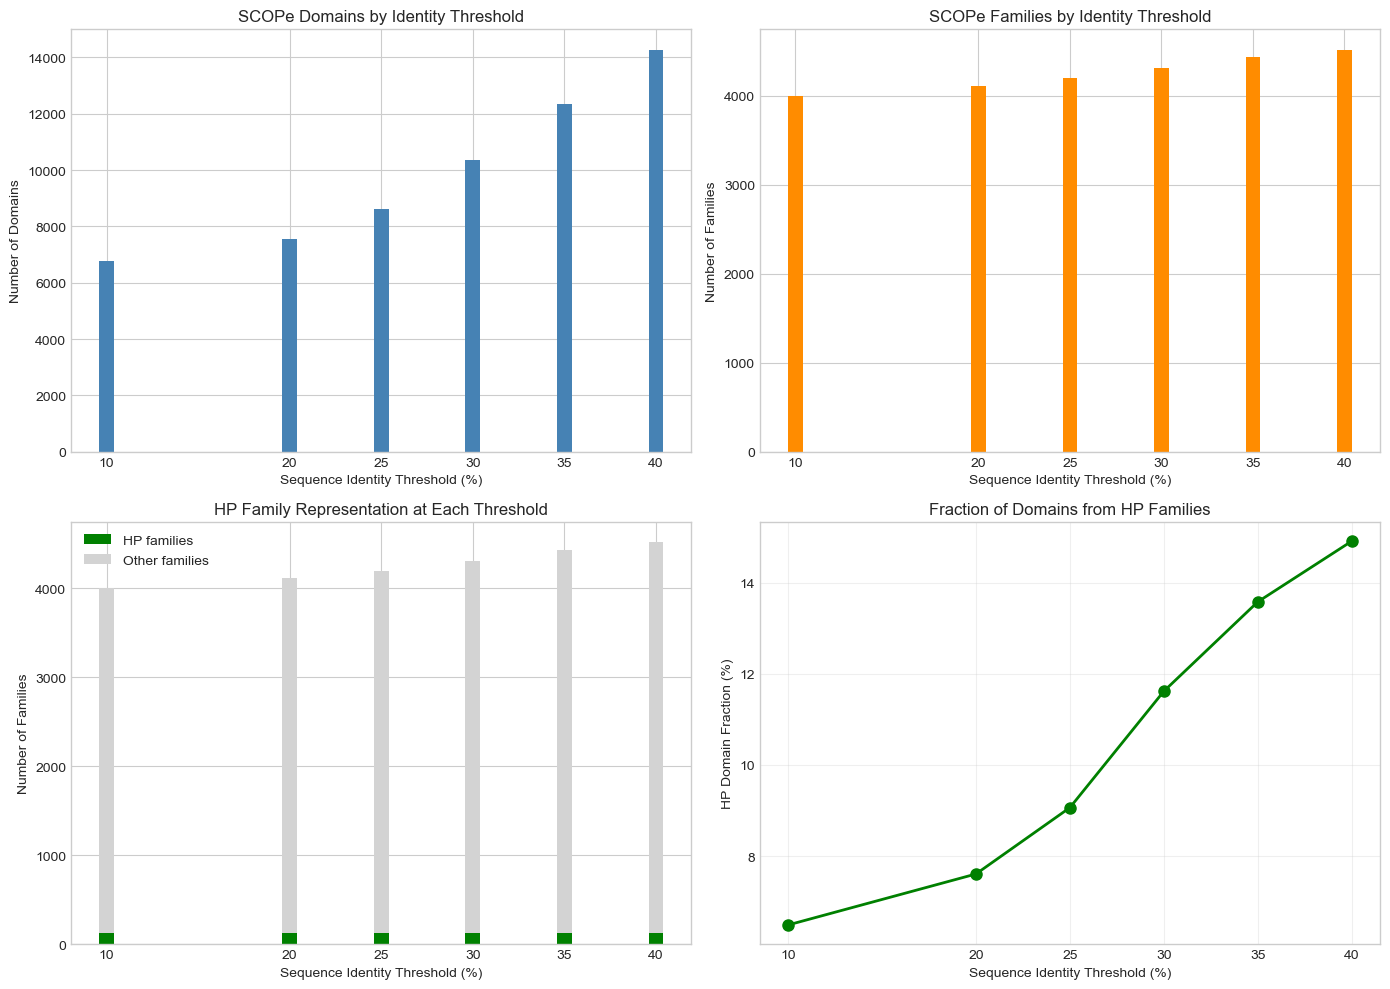

In [41]:
# Visualize threshold analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

thresholds_list = threshold_summary["threshold"].to_list()

# Plot 1: Number of domains at each threshold
ax = axes[0, 0]
ax.bar(thresholds_list, threshold_summary["n_domains"].to_list(), color="steelblue")
ax.set_xlabel("Sequence Identity Threshold (%)")
ax.set_ylabel("Number of Domains")
ax.set_title("SCOPe Domains by Identity Threshold")
ax.set_xticks(thresholds_list)

# Plot 2: Number of families at each threshold
ax = axes[0, 1]
ax.bar(thresholds_list, threshold_summary["n_families"].to_list(), color="darkorange")
ax.set_xlabel("Sequence Identity Threshold (%)")
ax.set_ylabel("Number of Families")
ax.set_title("SCOPe Families by Identity Threshold")
ax.set_xticks(thresholds_list)

# Plot 3: HP family representation
ax = axes[1, 0]
ax.bar(
    thresholds_list,
    hp_rep_df["hp_fams_represented"].to_list(),
    color="green",
    label="HP families",
)
ax.bar(
    thresholds_list,
    [
        t - h
        for t, h in zip(
            hp_rep_df["total_fams"].to_list(),
            hp_rep_df["hp_fams_represented"].to_list(),
        )
    ],
    bottom=hp_rep_df["hp_fams_represented"].to_list(),
    color="lightgray",
    label="Other families",
)
ax.set_xlabel("Sequence Identity Threshold (%)")
ax.set_ylabel("Number of Families")
ax.set_title("HP Family Representation at Each Threshold")
ax.set_xticks(thresholds_list)
ax.legend()

# Plot 4: HP domain fraction
ax = axes[1, 1]
ax.plot(
    thresholds_list,
    hp_rep_df["hp_domain_fraction"].to_list(),
    "go-",
    linewidth=2,
    markersize=8,
)
ax.set_xlabel("Sequence Identity Threshold (%)")
ax.set_ylabel("HP Domain Fraction (%)")
ax.set_title("Fraction of Domains from HP Families")
ax.set_xticks(thresholds_list)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "hp_k35_k36_scope_threshold_analysis_families.pdf", dpi=300, bbox_inches="tight"
)
plt.show()

In [42]:
# Summary statistics
print("\n" + "=" * 80)
print("SCOPE IDENTITY THRESHOLD ANALYSIS SUMMARY (FAMILIES)")
print("=" * 80)

print(f"\nHP families found: {len(hp_fam_strings)}")
print(f"\nRepresentation across thresholds:")
for row in hp_rep_df.iter_rows(named=True):
    print(
        f"  {row['threshold']}% identity: {row['hp_fams_represented']}/{row['total_fams']} families, "
        f"{row['hp_domains']}/{row['total_domains']} domains ({row['hp_domain_fraction']:.1f}%)"
    )

print(
    f"\nHP families represent {len(hp_fam_strings)/threshold_summary.filter(pl.col('threshold')==40)['n_families'][0]*100:.1f}% of SCOPe40 families"
)


SCOPE IDENTITY THRESHOLD ANALYSIS SUMMARY (FAMILIES)

HP families found: 136

Representation across thresholds:
  10% identity: 121/3999 families, 440/6784 domains (6.5%)
  20% identity: 123/4116 families, 574/7547 domains (7.6%)
  25% identity: 124/4197 families, 781/8617 domains (9.1%)
  30% identity: 127/4310 families, 1205/10370 domains (11.6%)
  35% identity: 129/4432 families, 1677/12346 domains (13.6%)
  40% identity: 130/4521 families, 2130/14280 domains (14.9%)

HP families represent 3.0% of SCOPe40 families


In [43]:
# Compare HP vs FoldSeek vs TEA representation at each SCOPe threshold
# This shows if HP finds matches in more divergent protein families

# FoldSeek families (SCOP column is the full family classification)
foldseek_fam_strings = set(
    row["SCOP"] for row in foldseek.iter_rows(named=True) if row["SCOP"]
)

# TEA families
tea_fam_strings = set(
    row["SCOP"] for row in tea_all.iter_rows(named=True) if row["SCOP"]
)

print(f"HP families: {len(hp_fams)}")
print(f"FoldSeek families: {len(foldseek_fam_strings)}")
print(f"TEA families: {len(tea_fam_strings)}")

HP families: 136
FoldSeek families: 943
TEA families: 950


In [44]:
# Analyze representation at each threshold for all methods
method_threshold_comparison = []

for th, df in scope_th_data.items():
    scope_fams_at_th = set(df["family"].unique().to_list())
    total_domains = len(df)

    # HP
    hp_fams_at_th = [s for s in hp_fam_strings if s in scope_fams_at_th]
    hp_domains = df.filter(pl.col("family").is_in(hp_fam_strings))

    # FoldSeek
    fs_fams_at_th = [s for s in foldseek_fam_strings if s in scope_fams_at_th]
    fs_domains = df.filter(pl.col("family").is_in(list(foldseek_fam_strings)))

    # TEA
    tea_fams_at_th = [s for s in tea_fam_strings if s in scope_fams_at_th]
    tea_domains = df.filter(pl.col("family").is_in(list(tea_fam_strings)))

    method_threshold_comparison.append(
        {
            "threshold": th,
            "total_fams": len(scope_fams_at_th),
            "total_domains": total_domains,
            "HP_fams": len(hp_fams_at_th),
            "HP_domains": len(hp_domains),
            "HP_fam_pct": len(hp_fams_at_th) / len(scope_fams_at_th) * 100,
            "HP_domain_pct": len(hp_domains) / total_domains * 100,
            "FoldSeek_fams": len(fs_fams_at_th),
            "FoldSeek_domains": len(fs_domains),
            "FoldSeek_fam_pct": len(fs_fams_at_th) / len(scope_fams_at_th) * 100,
            "FoldSeek_domain_pct": len(fs_domains) / total_domains * 100,
            "TEA_fams": len(tea_fams_at_th),
            "TEA_domains": len(tea_domains),
            "TEA_fam_pct": len(tea_fams_at_th) / len(scope_fams_at_th) * 100,
            "TEA_domain_pct": len(tea_domains) / total_domains * 100,
        }
    )

comparison_by_th = pl.DataFrame(method_threshold_comparison).sort("threshold")
print("Method comparison by SCOPe sequence identity threshold:")
print(comparison_by_th)

Method comparison by SCOPe sequence identity threshold:
shape: (6, 15)
┌───────────┬────────────┬────────────┬─────────┬───┬──────────┬───────────┬───────────┬───────────┐
│ threshold ┆ total_fams ┆ total_doma ┆ HP_fams ┆ … ┆ TEA_fams ┆ TEA_domai ┆ TEA_fam_p ┆ TEA_domai │
│ ---       ┆ ---        ┆ ins        ┆ ---     ┆   ┆ ---      ┆ ns        ┆ ct        ┆ n_pct     │
│ i64       ┆ i64        ┆ ---        ┆ i64     ┆   ┆ i64      ┆ ---       ┆ ---       ┆ ---       │
│           ┆            ┆ i64        ┆         ┆   ┆          ┆ i64       ┆ f64       ┆ f64       │
╞═══════════╪════════════╪════════════╪═════════╪═══╪══════════╪═══════════╪═══════════╪═══════════╡
│ 10        ┆ 3999       ┆ 6784       ┆ 121     ┆ … ┆ 840      ┆ 2223      ┆ 21.005251 ┆ 32.768278 │
│ 20        ┆ 4116       ┆ 7547       ┆ 123     ┆ … ┆ 858      ┆ 2534      ┆ 20.845481 ┆ 33.576255 │
│ 25        ┆ 4197       ┆ 8617       ┆ 124     ┆ … ┆ 878      ┆ 3012      ┆ 20.919705 ┆ 34.95416  │
│ 30        ┆ 4310  

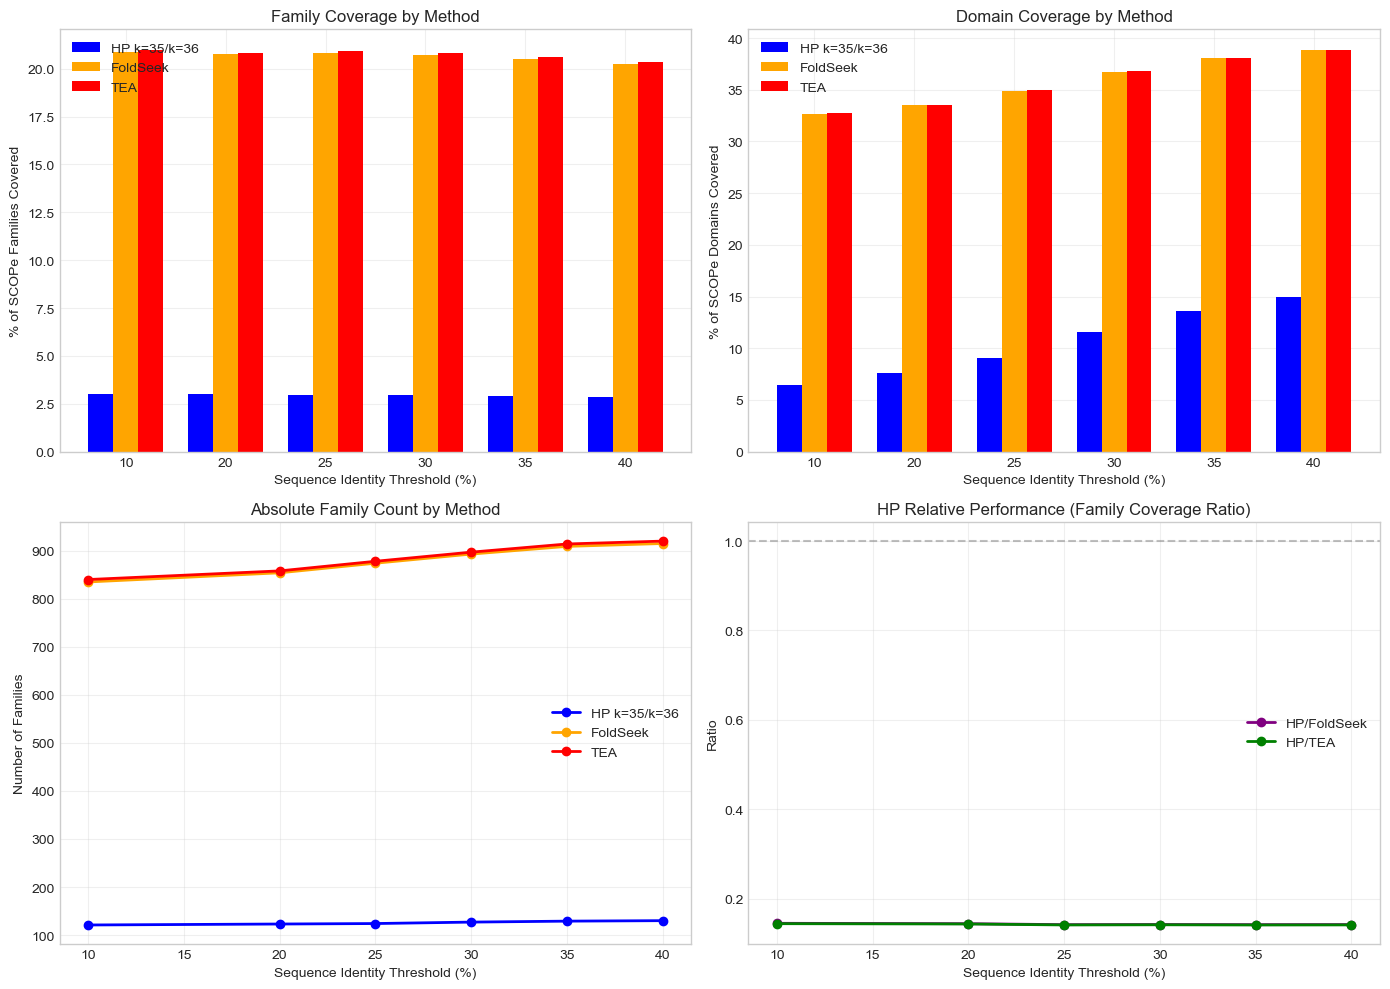

In [45]:
# Visualize HP vs FoldSeek vs TEA at different thresholds
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

thresholds = comparison_by_th["threshold"].to_list()
x = np.arange(len(thresholds))
width = 0.25

# Plot 1: Family coverage percentage
ax = axes[0, 0]
ax.bar(
    x - width,
    comparison_by_th["HP_fam_pct"].to_list(),
    width,
    label="HP k=35/k=36",
    color="blue",
)
ax.bar(
    x,
    comparison_by_th["FoldSeek_fam_pct"].to_list(),
    width,
    label="FoldSeek",
    color="orange",
)
ax.bar(
    x + width,
    comparison_by_th["TEA_fam_pct"].to_list(),
    width,
    label="TEA",
    color="red",
)
ax.set_xlabel("Sequence Identity Threshold (%)")
ax.set_ylabel("% of SCOPe Families Covered")
ax.set_title("Family Coverage by Method")
ax.set_xticks(x)
ax.set_xticklabels(thresholds)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Domain coverage percentage
ax = axes[0, 1]
ax.bar(
    x - width,
    comparison_by_th["HP_domain_pct"].to_list(),
    width,
    label="HP k=35/k=36",
    color="blue",
)
ax.bar(
    x,
    comparison_by_th["FoldSeek_domain_pct"].to_list(),
    width,
    label="FoldSeek",
    color="orange",
)
ax.bar(
    x + width,
    comparison_by_th["TEA_domain_pct"].to_list(),
    width,
    label="TEA",
    color="red",
)
ax.set_xlabel("Sequence Identity Threshold (%)")
ax.set_ylabel("% of SCOPe Domains Covered")
ax.set_title("Domain Coverage by Method")
ax.set_xticks(x)
ax.set_xticklabels(thresholds)
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Absolute family counts
ax = axes[1, 0]
ax.plot(
    thresholds,
    comparison_by_th["HP_fams"].to_list(),
    "bo-",
    label="HP k=35/k=36",
    linewidth=2,
)
ax.plot(
    thresholds,
    comparison_by_th["FoldSeek_fams"].to_list(),
    "o-",
    color="orange",
    label="FoldSeek",
    linewidth=2,
)
ax.plot(
    thresholds, comparison_by_th["TEA_fams"].to_list(), "ro-", label="TEA", linewidth=2
)
ax.set_xlabel("Sequence Identity Threshold (%)")
ax.set_ylabel("Number of Families")
ax.set_title("Absolute Family Count by Method")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: HP relative performance (HP/FoldSeek ratio)
ax = axes[1, 1]
hp_fs_ratio = [
    h / f if f > 0 else 0
    for h, f in zip(
        comparison_by_th["HP_fam_pct"].to_list(),
        comparison_by_th["FoldSeek_fam_pct"].to_list(),
    )
]
hp_tea_ratio = [
    h / t if t > 0 else 0
    for h, t in zip(
        comparison_by_th["HP_fam_pct"].to_list(),
        comparison_by_th["TEA_fam_pct"].to_list(),
    )
]
ax.plot(thresholds, hp_fs_ratio, "o-", color="purple", label="HP/FoldSeek", linewidth=2)
ax.plot(thresholds, hp_tea_ratio, "o-", color="green", label="HP/TEA", linewidth=2)
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Sequence Identity Threshold (%)")
ax.set_ylabel("Ratio")
ax.set_title("HP Relative Performance (Family Coverage Ratio)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "hp_vs_foldseek_tea_threshold_comparison_families.pdf", dpi=300, bbox_inches="tight"
)
plt.show()

HP families: 136
FoldSeek families: 943
TEA families: 950

HP UNIQUE FAMILIES AT EACH THRESHOLD
(Families found by HP but NOT by FoldSeek or TEA)

Threshold 10%:
  Total families in SCOPE at this threshold: 3999
  HP families: 121
  FoldSeek families: 835
  TEA families: 840
  HP finds but FoldSeek doesn't: 81 (66.9% of HP)
  HP finds but TEA doesn't: 81 (66.9% of HP)
  HP unique (not in FoldSeek OR TEA): 81 (66.9% of HP)

Threshold 20%:
  Total families in SCOPE at this threshold: 4116
  HP families: 123
  FoldSeek families: 854
  TEA families: 858
  HP finds but FoldSeek doesn't: 83 (67.5% of HP)
  HP finds but TEA doesn't: 83 (67.5% of HP)
  HP unique (not in FoldSeek OR TEA): 83 (67.5% of HP)

Threshold 25%:
  Total families in SCOPE at this threshold: 4197
  HP families: 124
  FoldSeek families: 874
  TEA families: 878
  HP finds but FoldSeek doesn't: 83 (66.9% of HP)
  HP finds but TEA doesn't: 83 (66.9% of HP)
  HP unique (not in FoldSeek OR TEA): 83 (66.9% of HP)

Threshold 30%

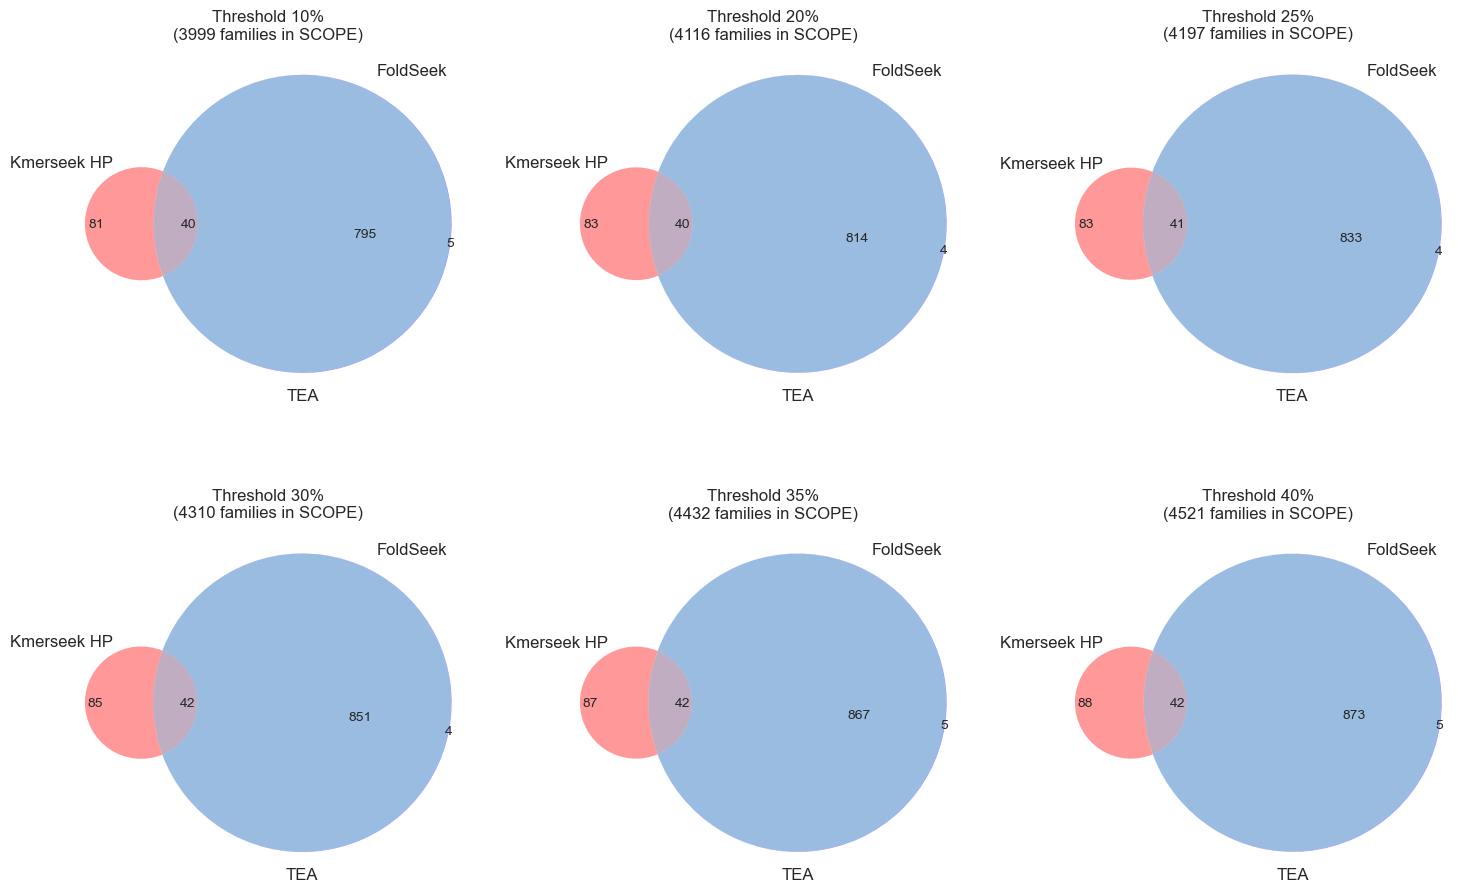

In [46]:
# Analyze: Are there FAMILIES HP finds at each threshold that FoldSeek/TEA miss?
from matplotlib_venn import venn3
from upsetplot import UpSet, from_memberships

print(f"HP families: {len(hp_fams)}")
print(f"FoldSeek families: {len(foldseek_fam_strings)}")
print(f"TEA families: {len(tea_fam_strings)}")

print("\n" + "=" * 70)
print("HP UNIQUE FAMILIES AT EACH THRESHOLD")
print("(Families found by HP but NOT by FoldSeek or TEA)")
print("=" * 70)

# Create figure with subplots for Venn diagrams
thresholds = sorted(scope_th_data.keys())
n_cols = 3
n_rows = (len(thresholds) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if len(thresholds) > 1 else [axes]

# Store data for UpSet plots
upset_data_by_th = {}

for idx, th in enumerate(thresholds):
    df = scope_th_data[th]
    scope_fams_at_th = set(df["family"].unique().to_list())

    # Families at this threshold for each method
    hp_at_th = hp_fams & scope_fams_at_th
    fs_at_th = foldseek_fam_strings & scope_fams_at_th
    tea_at_th = tea_fam_strings & scope_fams_at_th

    # Store for UpSet plot
    upset_data_by_th[th] = {
        "Kmerseek HP": hp_at_th,
        "FoldSeek": fs_at_th,
        "TEA": tea_at_th,
        "scope_fams": scope_fams_at_th,
    }

    # HP unique (not in FoldSeek or TEA)
    hp_unique = hp_at_th - (fs_at_th | tea_at_th)
    hp_not_fs = hp_at_th - fs_at_th
    hp_not_tea = hp_at_th - tea_at_th

    print(f"\nThreshold {th}%:")
    print(f"  Total families in SCOPE at this threshold: {len(scope_fams_at_th)}")
    print(f"  HP families: {len(hp_at_th)}")
    print(f"  FoldSeek families: {len(fs_at_th)}")
    print(f"  TEA families: {len(tea_at_th)}")
    if len(hp_at_th) > 0:
        print(
            f"  HP finds but FoldSeek doesn't: {len(hp_not_fs)} ({len(hp_not_fs)/len(hp_at_th)*100:.1f}% of HP)"
        )
        print(
            f"  HP finds but TEA doesn't: {len(hp_not_tea)} ({len(hp_not_tea)/len(hp_at_th)*100:.1f}% of HP)"
        )
        print(
            f"  HP unique (not in FoldSeek OR TEA): {len(hp_unique)} ({len(hp_unique)/len(hp_at_th)*100:.1f}% of HP)"
        )

    # Create Venn diagram
    ax = axes[idx]
    venn = venn3(
        [hp_at_th, fs_at_th, tea_at_th],
        set_labels=("Kmerseek HP", "FoldSeek", "TEA"),
        ax=ax,
    )
    ax.set_title(f"Threshold {th}%\n({len(scope_fams_at_th)} families in SCOPE)")

# Hide empty subplots
for idx in range(len(thresholds), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.savefig("hp_family_venn_by_threshold.pdf", dpi=300, bbox_inches="tight")
plt.show()

/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the or

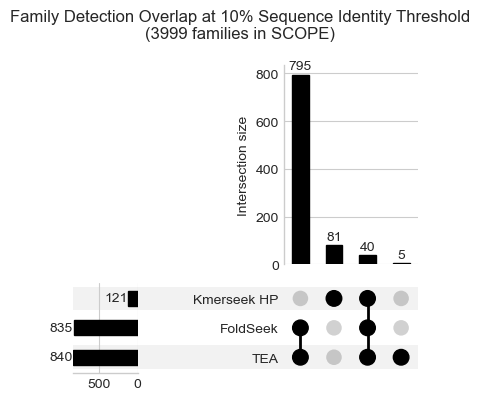

/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the or

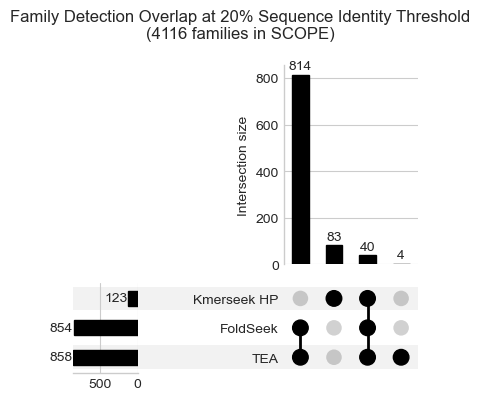

/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the or

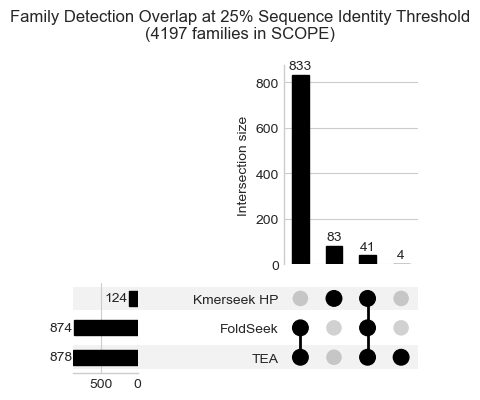

/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the or

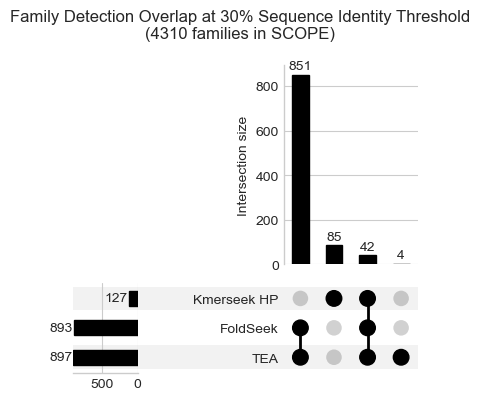

/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the or

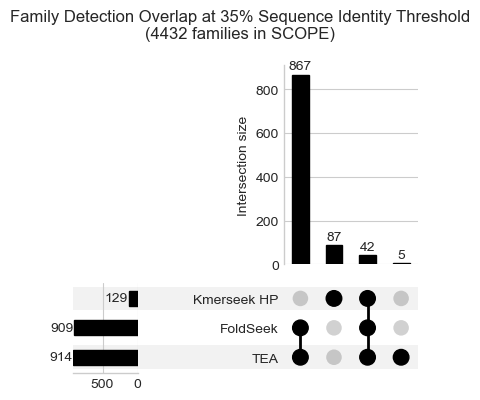

/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/olga/anaconda3/envs/2025-kmerseek-analysis/lib/python3.13/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the or

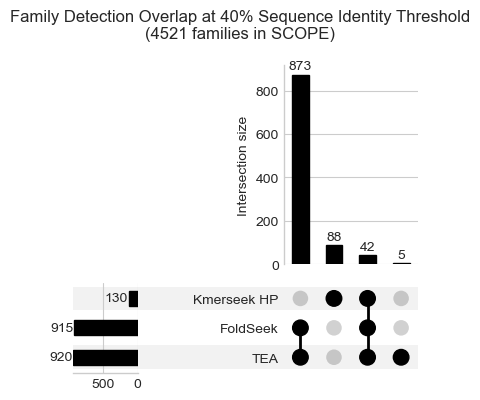


SUMMARY: KMERSEEK HP PERFORMANCE AT LOW VS HIGH SIMILARITY THRESHOLDS (FAMILIES)

At 10% sequence identity (most divergent proteins):
  Kmerseek HP covers 3.0% of families
  FoldSeek covers 20.9% of families
  TEA covers 21.0% of families
  Kmerseek HP/FoldSeek ratio: 0.145
  Kmerseek HP/TEA ratio: 0.144

At 40% sequence identity (less divergent proteins):
  Kmerseek HP covers 2.9% of families
  FoldSeek covers 20.2% of families
  TEA covers 20.3% of families
  Kmerseek HP/FoldSeek ratio: 0.142
  Kmerseek HP/TEA ratio: 0.141

Conclusion:
  Kmerseek HP is RELATIVELY BETTER vs FoldSeek at low similarity (0.145 vs 0.142)
  Kmerseek HP is RELATIVELY BETTER vs TEA at low similarity (0.144 vs 0.141)

Kmerseek HP-unique families at 10% threshold (81 families):
  a.102.2.1
  a.104.1.0
  a.118.12.1
  a.118.29.1
  a.118.9.1
  a.123.1.1
  a.127.1.0
  a.128.1.0
  a.196.1.1
  a.211.1.2
  a.266.1.2
  a.298.1.1
  a.47.3.1
  a.93.1.2
  b.179.1.1
  b.18.1.19
  b.29.1.2
  b.47.1.1
  c.105.1.1
  c.108.1

In [47]:
# UpSet plots for each threshold
for th in thresholds:
    data = upset_data_by_th[th]
    hp_at_th = data["Kmerseek HP"]
    fs_at_th = data["FoldSeek"]
    tea_at_th = data["TEA"]

    # Build membership list for UpSet plot
    all_fams = hp_at_th | fs_at_th | tea_at_th

    memberships = []
    for fam in all_fams:
        members = []
        if fam in hp_at_th:
            members.append("Kmerseek HP")
        if fam in fs_at_th:
            members.append("FoldSeek")
        if fam in tea_at_th:
            members.append("TEA")
        memberships.append(members)

    # Create UpSet data
    upset_series = from_memberships(memberships)

    # Plot
    fig = plt.figure(figsize=(10, 6))
    upset = UpSet(
        upset_series, show_counts=True, sort_by="cardinality", subset_size="count"
    )
    upset.plot(fig=fig)
    plt.suptitle(
        f'Family Detection Overlap at {th}% Sequence Identity Threshold\n({len(data["scope_fams"])} families in SCOPE)',
        fontsize=12,
        y=1.02,
    )
    plt.savefig(f"hp_family_upset_th{th}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

# Summary comparison
print("\n" + "=" * 70)
print(
    "SUMMARY: KMERSEEK HP PERFORMANCE AT LOW VS HIGH SIMILARITY THRESHOLDS (FAMILIES)"
)
print("=" * 70)

# Compare lowest vs highest threshold
low_th = comparison_by_th.filter(pl.col("threshold") == min(thresholds)).to_dicts()[0]
high_th = comparison_by_th.filter(pl.col("threshold") == max(thresholds)).to_dicts()[0]

print(f"\nAt {min(thresholds)}% sequence identity (most divergent proteins):")
print(f"  Kmerseek HP covers {low_th['HP_fam_pct']:.1f}% of families")
print(f"  FoldSeek covers {low_th['FoldSeek_fam_pct']:.1f}% of families")
print(f"  TEA covers {low_th['TEA_fam_pct']:.1f}% of families")
print(
    f"  Kmerseek HP/FoldSeek ratio: {low_th['HP_fam_pct']/low_th['FoldSeek_fam_pct']:.3f}"
)
print(f"  Kmerseek HP/TEA ratio: {low_th['HP_fam_pct']/low_th['TEA_fam_pct']:.3f}")

print(f"\nAt {max(thresholds)}% sequence identity (less divergent proteins):")
print(f"  Kmerseek HP covers {high_th['HP_fam_pct']:.1f}% of families")
print(f"  FoldSeek covers {high_th['FoldSeek_fam_pct']:.1f}% of families")
print(f"  TEA covers {high_th['TEA_fam_pct']:.1f}% of families")
print(
    f"  Kmerseek HP/FoldSeek ratio: {high_th['HP_fam_pct']/high_th['FoldSeek_fam_pct']:.3f}"
)
print(f"  Kmerseek HP/TEA ratio: {high_th['HP_fam_pct']/high_th['TEA_fam_pct']:.3f}")

# Is HP relatively better at low thresholds?
low_ratio_fs = low_th["HP_fam_pct"] / low_th["FoldSeek_fam_pct"]
high_ratio_fs = high_th["HP_fam_pct"] / high_th["FoldSeek_fam_pct"]
low_ratio_tea = low_th["HP_fam_pct"] / low_th["TEA_fam_pct"]
high_ratio_tea = high_th["HP_fam_pct"] / high_th["TEA_fam_pct"]

print(f"\nConclusion:")
if low_ratio_fs > high_ratio_fs:
    print(
        f"  Kmerseek HP is RELATIVELY BETTER vs FoldSeek at low similarity ({low_ratio_fs:.3f} vs {high_ratio_fs:.3f})"
    )
else:
    print(
        f"  Kmerseek HP is RELATIVELY WORSE vs FoldSeek at low similarity ({low_ratio_fs:.3f} vs {high_ratio_fs:.3f})"
    )

if low_ratio_tea > high_ratio_tea:
    print(
        f"  Kmerseek HP is RELATIVELY BETTER vs TEA at low similarity ({low_ratio_tea:.3f} vs {high_ratio_tea:.3f})"
    )
else:
    print(
        f"  Kmerseek HP is RELATIVELY WORSE vs TEA at low similarity ({low_ratio_tea:.3f} vs {high_ratio_tea:.3f})"
    )

# Print the unique HP families at the lowest threshold
lowest_th = min(thresholds)
hp_unique_at_low = upset_data_by_th[lowest_th]["Kmerseek HP"] - (
    upset_data_by_th[lowest_th]["FoldSeek"] | upset_data_by_th[lowest_th]["TEA"]
)
print(
    f"\nKmerseek HP-unique families at {lowest_th}% threshold ({len(hp_unique_at_low)} families):"
)
for fam in sorted(hp_unique_at_low)[:20]:
    print(f"  {fam}")
if len(hp_unique_at_low) > 20:
    print(f"  ... and {len(hp_unique_at_low) - 20} more")

## 7c. Protein Disorder Analysis

Analyze intrinsic disorder propensity of HP superfamilies using sequence composition.

In [48]:
# Compute disorder-related sequence features
# Disorder-promoting residues: A, R, G, Q, S, P, E, K (charged/polar, small)
# Order-promoting residues: W, C, F, I, Y, V, L, N (hydrophobic, aromatic)


def compute_disorder_features(seq):
    """Compute disorder-related features from amino acid sequence."""
    if not seq or len(seq) == 0:
        return {
            "disorder_propensity": None,
            "charge_fraction": None,
            "hydrophobic_fraction": None,
            "proline_fraction": None,
            "complexity": None,
        }

    seq = seq.upper()
    seq_len = len(seq)

    # Disorder-promoting residues (high in IDRs)
    disorder_promoting = set("ARGQSPEK")
    disorder_count = sum(1 for aa in seq if aa in disorder_promoting)

    # Order-promoting residues (low in IDRs)
    order_promoting = set("WCFIYVLN")
    order_count = sum(1 for aa in seq if aa in order_promoting)

    # Charged residues (high in IDRs)
    charged = set("RKDE")
    charged_count = sum(1 for aa in seq if aa in charged)

    # Hydrophobic residues (low in IDRs)
    hydrophobic = set("AVILMFYW")
    hydrophobic_count = sum(1 for aa in seq if aa in hydrophobic)

    # Proline content (high in IDRs)
    proline_count = seq.count("P")

    # Sequence complexity (Shannon entropy)
    from collections import Counter
    import math

    aa_counts = Counter(seq)
    entropy = -sum(
        (c / seq_len) * math.log2(c / seq_len) for c in aa_counts.values() if c > 0
    )
    max_entropy = math.log2(min(20, seq_len))  # max possible entropy
    complexity = entropy / max_entropy if max_entropy > 0 else 0

    # Disorder propensity: ratio of disorder-promoting to order-promoting
    disorder_propensity = disorder_count / (
        order_count + 1
    )  # +1 to avoid division by zero

    return {
        "disorder_propensity": disorder_propensity,
        "charge_fraction": charged_count / seq_len,
        "hydrophobic_fraction": hydrophobic_count / seq_len,
        "proline_fraction": proline_count / seq_len,
        "complexity": complexity,
    }


# Test on a sample sequence
test_seq = scope_annotations["seq"][0]
print(f"Test sequence (first 50 chars): {test_seq[:50]}...")
print(f"Disorder features: {compute_disorder_features(test_seq)}")

Test sequence (first 50 chars): SLFEQLGGQAAVQAVTAQFYANIQADATVATFFNGIDMPNQTNKTAAFLC...
Disorder features: {'disorder_propensity': 1.2790697674418605, 'charge_fraction': 0.10344827586206896, 'hydrophobic_fraction': 0.49137931034482757, 'proline_fraction': 0.017241379310344827, 'complexity': 0.8786641661368528}


In [49]:
# Compute disorder features for all SCOPe domains
print("Computing disorder features for all SCOPe domains...")

disorder_data = []
for row in scope_annotations.iter_rows(named=True):
    features = compute_disorder_features(row["seq"])
    features["sid"] = row["sid"]
    features["superfamily"] = row["superfamily"]
    features["seq_len"] = row["seq_len"]
    disorder_data.append(features)

disorder_df = pl.DataFrame(disorder_data)
print(f"Computed disorder features for {len(disorder_df)} domains")
disorder_df.head()

Computing disorder features for all SCOPe domains...
Computed disorder features for 14280 domains


disorder_propensity,charge_fraction,hydrophobic_fraction,proline_fraction,complexity,sid,superfamily,seq_len
f64,f64,f64,f64,f64,str,str,i64
1.27907,0.103448,0.491379,0.017241,0.878664,"""d1dlwa_""","""a.1.1""",116
1.488372,0.19685,0.456693,0.047244,0.918788,"""d2gkma_""","""a.1.1""",127
1.6,0.309524,0.428571,0.039683,0.931049,"""d1ngka_""","""a.1.1""",126
1.657895,0.2421875,0.421875,0.0703125,0.93226,"""d2bkma_""","""a.1.1""",128
1.12766,0.252033,0.447154,0.00813,0.917811,"""d4i0va_""","""a.1.1""",123


In [50]:
# Aggregate disorder features by superfamily
sfam_disorder = (
    disorder_df.group_by("superfamily")
    .agg(
        [
            pl.len().alias("n_domains"),
            pl.col("disorder_propensity").mean().alias("avg_disorder_propensity"),
            pl.col("charge_fraction").mean().alias("avg_charge_fraction"),
            pl.col("hydrophobic_fraction").mean().alias("avg_hydrophobic_fraction"),
            pl.col("proline_fraction").mean().alias("avg_proline_fraction"),
            pl.col("complexity").mean().alias("avg_complexity"),
        ]
    )
    .sort("avg_disorder_propensity", descending=True)
)

print("Superfamilies ranked by disorder propensity (highest first):")
sfam_disorder.head(15)

Superfamilies ranked by disorder propensity (highest first):


superfamily,n_domains,avg_disorder_propensity,avg_charge_fraction,avg_hydrophobic_fraction,avg_proline_fraction,avg_complexity
str,u32,f64,f64,f64,f64,f64
"""f.23.21""",1,3.833333,0.459016,0.360656,0.0,0.739781
"""a.154.1""",1,3.047619,0.298969,0.405498,0.017182,0.822169
"""a.137.5""",1,3.0,0.422222,0.311111,0.0,0.868527
"""a.2.8""",1,3.0,0.472222,0.347222,0.0,0.790403
"""a.137.15""",1,2.901639,0.25,0.45,0.057143,0.844848
…,…,…,…,…,…,…
"""a.7.16""",1,2.52381,0.313253,0.39759,0.012048,0.851799
"""c.9.2""",1,2.5,0.380282,0.274648,0.042254,0.902054
"""a.34.3""",1,2.5,0.362069,0.362069,0.034483,0.822415


In [51]:
# Compare disorder of HP superfamilies vs all superfamilies
hp_sfams_list = list(hp_sfams)  # from earlier cell

hp_disorder = sfam_disorder.filter(pl.col("superfamily").is_in(hp_sfams_list))

print("\n" + "=" * 80)
print("DISORDER COMPARISON: HP vs All SCOPe Superfamilies")
print("=" * 80)

# Compare averages
metrics = [
    "avg_disorder_propensity",
    "avg_charge_fraction",
    "avg_hydrophobic_fraction",
    "avg_proline_fraction",
    "avg_complexity",
]

print(f"\n{'Metric':<30} {'HP (k=35/36)':<15} {'All SCOPe':<15} {'Difference':<15}")
print("-" * 75)

for metric in metrics:
    hp_val = hp_disorder[metric].mean()
    all_val = sfam_disorder[metric].mean()
    diff = hp_val - all_val
    diff_pct = (diff / all_val * 100) if all_val != 0 else 0
    print(
        f"{metric:<30} {hp_val:>12.4f}   {all_val:>12.4f}   {diff:>+.4f} ({diff_pct:>+.1f}%)"
    )


DISORDER COMPARISON: HP vs All SCOPe Superfamilies

Metric                         HP (k=35/36)    All SCOPe       Difference     
---------------------------------------------------------------------------
avg_disorder_propensity              1.2823         1.3220   -0.0397 (-3.0%)
avg_charge_fraction                  0.2299         0.2529   -0.0230 (-9.1%)
avg_hydrophobic_fraction             0.4296         0.4073   +0.0223 (+5.5%)
avg_proline_fraction                 0.0442         0.0432   +0.0009 (+2.1%)
avg_complexity                       0.9339         0.9132   +0.0206 (+2.3%)


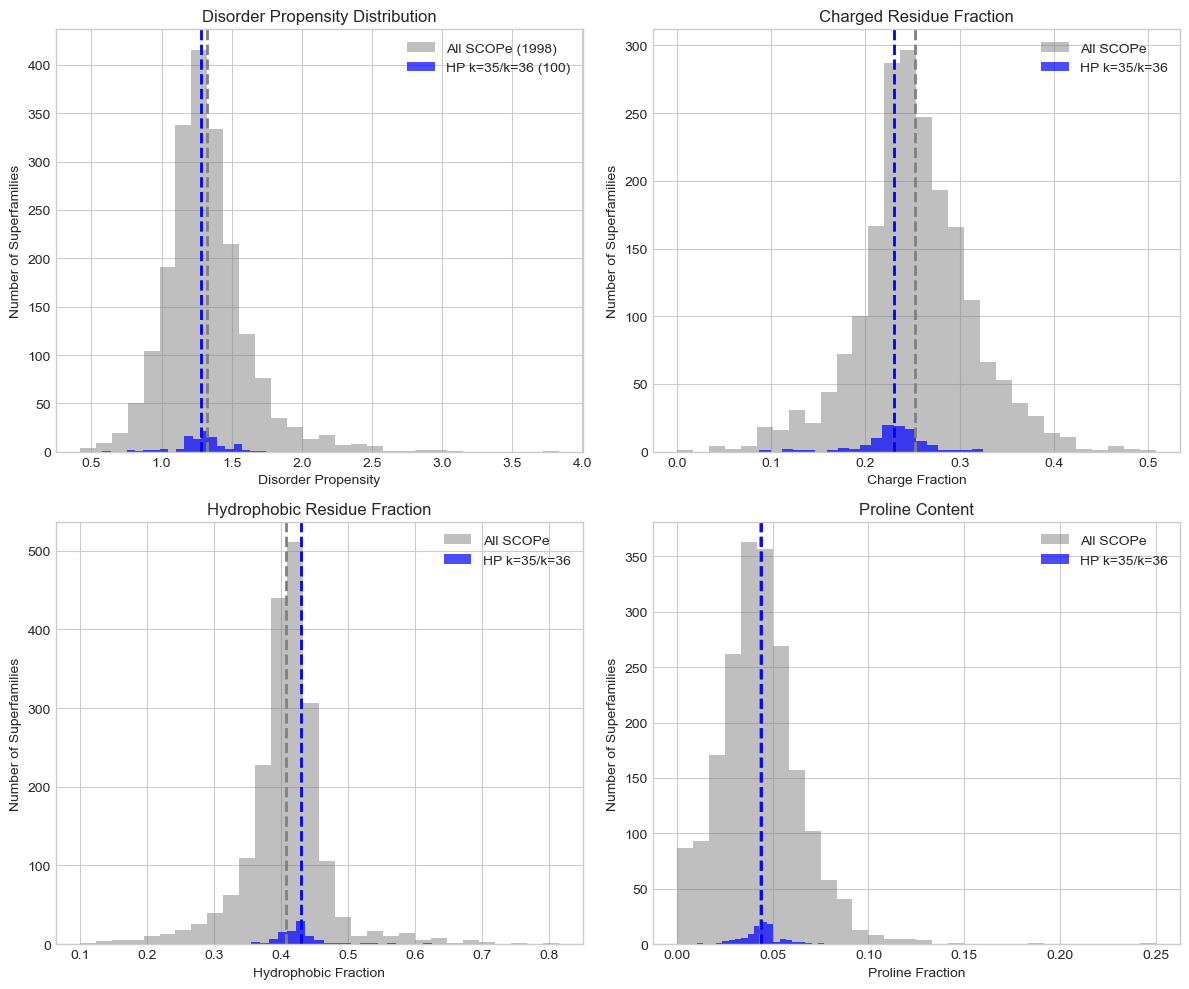

In [52]:
# Visualize disorder comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Get data
hp_disorder_vals = hp_disorder["avg_disorder_propensity"].to_list()
all_disorder_vals = sfam_disorder["avg_disorder_propensity"].to_list()

hp_charge_vals = hp_disorder["avg_charge_fraction"].to_list()
all_charge_vals = sfam_disorder["avg_charge_fraction"].to_list()

hp_hydro_vals = hp_disorder["avg_hydrophobic_fraction"].to_list()
all_hydro_vals = sfam_disorder["avg_hydrophobic_fraction"].to_list()

hp_proline_vals = hp_disorder["avg_proline_fraction"].to_list()
all_proline_vals = sfam_disorder["avg_proline_fraction"].to_list()

# Plot 1: Disorder propensity
ax = axes[0, 0]
ax.hist(
    all_disorder_vals,
    bins=30,
    alpha=0.5,
    label=f"All SCOPe ({len(all_disorder_vals)})",
    color="gray",
)
ax.hist(
    hp_disorder_vals,
    bins=20,
    alpha=0.7,
    label=f"HP k=35/k=36 ({len(hp_disorder_vals)})",
    color="blue",
)
ax.axvline(np.mean(all_disorder_vals), color="gray", linestyle="--", linewidth=2)
ax.axvline(np.mean(hp_disorder_vals), color="blue", linestyle="--", linewidth=2)
ax.set_xlabel("Disorder Propensity")
ax.set_ylabel("Number of Superfamilies")
ax.set_title("Disorder Propensity Distribution")
ax.legend()

# Plot 2: Charge fraction
ax = axes[0, 1]
ax.hist(all_charge_vals, bins=30, alpha=0.5, label="All SCOPe", color="gray")
ax.hist(hp_charge_vals, bins=20, alpha=0.7, label="HP k=35/k=36", color="blue")
ax.axvline(np.mean(all_charge_vals), color="gray", linestyle="--", linewidth=2)
ax.axvline(np.mean(hp_charge_vals), color="blue", linestyle="--", linewidth=2)
ax.set_xlabel("Charge Fraction")
ax.set_ylabel("Number of Superfamilies")
ax.set_title("Charged Residue Fraction")
ax.legend()

# Plot 3: Hydrophobic fraction
ax = axes[1, 0]
ax.hist(all_hydro_vals, bins=30, alpha=0.5, label="All SCOPe", color="gray")
ax.hist(hp_hydro_vals, bins=20, alpha=0.7, label="HP k=35/k=36", color="blue")
ax.axvline(np.mean(all_hydro_vals), color="gray", linestyle="--", linewidth=2)
ax.axvline(np.mean(hp_hydro_vals), color="blue", linestyle="--", linewidth=2)
ax.set_xlabel("Hydrophobic Fraction")
ax.set_ylabel("Number of Superfamilies")
ax.set_title("Hydrophobic Residue Fraction")
ax.legend()

# Plot 4: Proline fraction
ax = axes[1, 1]
ax.hist(all_proline_vals, bins=30, alpha=0.5, label="All SCOPe", color="gray")
ax.hist(hp_proline_vals, bins=20, alpha=0.7, label="HP k=35/k=36", color="blue")
ax.axvline(np.mean(all_proline_vals), color="gray", linestyle="--", linewidth=2)
ax.axvline(np.mean(hp_proline_vals), color="blue", linestyle="--", linewidth=2)
ax.set_xlabel("Proline Fraction")
ax.set_ylabel("Number of Superfamilies")
ax.set_title("Proline Content")
ax.legend()

plt.tight_layout()
plt.savefig("hp_k35_k36_disorder_analysis.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [53]:
# Show HP superfamilies with highest and lowest disorder
hp_disorder_ranked = hp_disorder.sort("avg_disorder_propensity", descending=True)

print("\nHP superfamilies with HIGHEST disorder propensity (top 10):")
print(hp_disorder_ranked.head(10))

print("\nHP superfamilies with LOWEST disorder propensity (bottom 10):")
print(hp_disorder_ranked.tail(10))


HP superfamilies with HIGHEST disorder propensity (top 10):
shape: (10, 7)
┌─────────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬─────────────┐
│ superfamily ┆ n_domains ┆ avg_disorder ┆ avg_charge_f ┆ avg_hydropho ┆ avg_proline ┆ avg_complex │
│ ---         ┆ ---       ┆ _propensity  ┆ raction      ┆ bic_fraction ┆ _fraction   ┆ ity         │
│ str         ┆ u32       ┆ ---          ┆ ---          ┆ ---          ┆ ---         ┆ ---         │
│             ┆           ┆ f64          ┆ f64          ┆ f64          ┆ f64         ┆ f64         │
╞═════════════╪═══════════╪══════════════╪══════════════╪══════════════╪═════════════╪═════════════╡
│ d.258.1     ┆ 3         ┆ 1.747154     ┆ 0.238563     ┆ 0.397265     ┆ 0.044693    ┆ 0.931447    │
│ a.298.1     ┆ 3         ┆ 1.642761     ┆ 0.159746     ┆ 0.43352      ┆ 0.04186     ┆ 0.869456    │
│ a.196.1     ┆ 1         ┆ 1.586957     ┆ 0.268966     ┆ 0.386207     ┆ 0.055172    ┆ 0.941641    │
│ c.122.1     ┆

In [54]:
# Save disorder analysis
sfam_disorder.write_csv("scope40_superfamily_disorder.csv")
hp_disorder.write_csv("hp_k35_k36_superfamily_disorder.csv")
print(
    "Saved disorder analysis to scope40_superfamily_disorder.csv and hp_k35_k36_superfamily_disorder.csv"
)

Saved disorder analysis to scope40_superfamily_disorder.csv and hp_k35_k36_superfamily_disorder.csv


## 8. Save Results

In [55]:
# Save HP k=35 and k=36 ROCX data
hp_k35_rocx.write_csv("hp_k35_tfidf1000_rocx.csv")
hp_k36_rocx.write_csv("hp_k36_tfidf1000_rocx.csv")
print("Saved HP k=35 ROCX to hp_k35_tfidf1000_rocx.csv")
print("Saved HP k=36 ROCX to hp_k36_tfidf1000_rocx.csv")

# Save family comparison
fam_comparison_df.write_csv("hp_k35_k36_vs_foldseek_tea_fam_comparison.csv")
print(
    f"Saved family comparison ({len(fam_comparison_df)} families) to hp_k35_k36_vs_foldseek_tea_fam_comparison.csv"
)

# Save superfamily comparison
sfam_comparison_df.write_csv("hp_k35_k36_vs_foldseek_tea_sfam_comparison.csv")
print(
    f"Saved superfamily comparison ({len(sfam_comparison_df)} superfamilies) to hp_k35_k36_vs_foldseek_tea_sfam_comparison.csv"
)

Saved HP k=35 ROCX to hp_k35_tfidf1000_rocx.csv
Saved HP k=36 ROCX to hp_k36_tfidf1000_rocx.csv
Saved family comparison (2 families) to hp_k35_k36_vs_foldseek_tea_fam_comparison.csv
Saved superfamily comparison (2 superfamilies) to hp_k35_k36_vs_foldseek_tea_sfam_comparison.csv


## 9. Summary

In [56]:
print("=" * 80)
print("SUMMARY: HP k=35 and k=36 vs FoldSeek/TEA")
print("=" * 80)

print(f"\n1. PERFORMANCE (AUC at Family and Superfamily levels):")
print(f"   {'Method':<15} {'Family AUC':<15} {'Superfamily AUC':<15} {'Queries':<10}")
print(f"   {'-'*55}")
print(
    f"   {'HP k=35':<15} {hp_aucs['k35']['fam']:<15.4f} {hp_aucs['k35']['sfam']:<15.4f} {len(hp_k35_rocx):<10}"
)
print(
    f"   {'HP k=36':<15} {hp_aucs['k36']['fam']:<15.4f} {hp_aucs['k36']['sfam']:<15.4f} {len(hp_k36_rocx):<10}"
)
print(f"   {'FoldSeek':<15} {'N/A':<15} {'0.574':<15} {'5,713':<10}")
print(f"   {'TEA':<15} {'N/A':<15} {'0.580':<15} {'5,737':<10}")

print(f"\n2. FAMILY COVERAGE:")
print(f"   HP k=35: {len(hp_k35_fams)} families")
print(f"   HP k=36: {len(hp_k36_fams)} families")
print(f"   HP combined: {len(hp_combined_fams)} unique families")
print(f"   Families unique to HP: {len(hp_unique_fams)}")

print(f"\n3. SUPERFAMILY COVERAGE:")
print(f"   HP k=35: {len(hp_k35_sfams)} superfamilies")
print(f"   HP k=36: {len(hp_k36_sfams)} superfamilies")
print(f"   HP combined: {len(hp_combined_sfams)} unique superfamilies")
print(f"   Superfamilies unique to HP: {len(hp_unique_sfams)}")

print(f"\n4. QUERY OVERLAP:")
print(
    f"   HP k=35 ∩ k=36 families: {len(k35_k36_fam_overlap)} ({len(k35_k36_fam_overlap)/len(hp_combined_fams)*100:.1f}% of HP combined)"
)
print(
    f"   HP k=35 ∩ k=36 superfamilies: {len(k35_k36_sfam_overlap)} ({len(k35_k36_sfam_overlap)/len(hp_combined_sfams)*100:.1f}% of HP combined)"
)

print(f"\n5. KEY FINDING:")
print(f"   HP k=35 is the minimum k-size to outperform FoldSeek/TEA (AUC >= 0.58)")
print(
    f"   at the superfamily level with {len(hp_k35_rocx)} queries using TF-IDF > 1000."
)

SUMMARY: HP k=35 and k=36 vs FoldSeek/TEA

1. PERFORMANCE (AUC at Family and Superfamily levels):
   Method          Family AUC      Superfamily AUC Queries   
   -------------------------------------------------------
   HP k=35         0.3561          0.5873          212       
   HP k=36         0.4258          0.6914          128       
   FoldSeek        N/A             0.574           5,713     
   TEA             N/A             0.580           5,737     

2. FAMILY COVERAGE:
   HP k=35: 2 families
   HP k=36: 2 families
   HP combined: 2 unique families
   Families unique to HP: 0

3. SUPERFAMILY COVERAGE:
   HP k=35: 2 superfamilies
   HP k=36: 2 superfamilies
   HP combined: 2 unique superfamilies
   Superfamilies unique to HP: 1

4. QUERY OVERLAP:
   HP k=35 ∩ k=36 families: 2 (100.0% of HP combined)
   HP k=35 ∩ k=36 superfamilies: 2 (100.0% of HP combined)

5. KEY FINDING:
   HP k=35 is the minimum k-size to outperform FoldSeek/TEA (AUC >= 0.58)
   at the superfamily level